In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp


In [ ]:
fft=lambda x: sp.fftpack.fftshift(sp.fftpack.fft2(sp.fftpack.fftshift(x)))

import cupy as cp
import cupyx.scipy.fft as cpfft

def find_grains_gpu(img, ws=128):
    # --- grayscale ---
    if len(img.shape) > 2:
        if img.shape[-1] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        elif img.shape[-1] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)
        else:
            img = img[:, :, 0]

    # --- sharpening + threshold (same as original, on CPU) ---
    sharpening_kernel = np.array(
        [[-1, 1, 1, 1, -1],
         [-1, 1, 1, 1, -1],
         [-1, 1, 1.5, 1, -1],
         [-1, 1, 1, 1, -1],
         [-1, -1, -1, -1, -1]], dtype=np.float32)
    th = cv2.filter2D(img, -1, sharpening_kernel)
    th = np.array((th - th.min()) / np.amax(th - th.min()) * 255, dtype=np.uint8)
    th = cv2.adaptiveThreshold(
        th, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, .1
    ).astype(np.float32) / 255.0

    M, N = th.shape
    H, W = M - ws, N - ws
    size = ws
    cy = cx = size // 2

    # --- chunked GPU FFT (no full tile extraction) ---
    chunk_size = 5000
    n_tiles    = H * W
    angles_np  = np.zeros(n_tiles, dtype=np.float32)

    for start in range(0, n_tiles, chunk_size):
        end    = min(start + chunk_size, n_tiles)
        # convert flat indices back to (i, j) positions
        idxs   = np.arange(start, end)
        is_    = idxs // W
        js_    = idxs % W
        # extract tiles for this chunk only
        chunk  = np.stack([th[i:i+ws, j:j+ws] for i, j in zip(is_, js_)])
        chunk  = cp.asarray(chunk)
        chunk  = cpfft.fftshift(chunk, axes=(-2, -1))
        ft     = cpfft.fft2(chunk, axes=(-2, -1))
        ft     = cpfft.fftshift(ft, axes=(-2, -1))
        ft_mag = cp.abs(ft)
        ft_mag[:, cy, cx] = 0
        flat   = ft_mag.reshape(ft_mag.shape[0], -1)
        flat_idx = cp.argmax(flat, axis=1)
        py     = flat_idx // size
        px     = flat_idx % size
        dy     = (py - cy).astype(cp.float32)
        dx     = (px - cx).astype(cp.float32)
        angles_np[start:end] = cp.asnumpy(cp.arctan2(dy, dx))
        print(f"  FFT progress: {end}/{n_tiles} tiles", end='\r')

    grain_angles = angles_np.reshape(H, W) % (np.pi / 3)
    return grain_angles

In [ ]:
from skimage.segmentation import felzenszwalb, mark_boundaries
from skimage.measure import regionprops
from skimage import graph
from skimage.color import hsv2rgb as hsv_to_rgb
from scipy.fftpack import fft2, fftshift
import tifffile
from scipy import stats
import cv2

outputs={}
outputs['grain_orientations']=[]
outputs['rag']=[]
outputs['cidx']=[]
outputs['ridx']=[]
outputs['num_grains']=[]
outputs['mean_grain_size']=[]
from pathlib import Path
for ridx in range(1, 5):
    for cidx in range(1, 14):
        if not Path(fr"/mnt/c/Users/Jet/Documents/PhD Data/PANI/020426/r{ridx}_c{cidx}.tif").exists():
            print(f"File not found for Row {ridx}, Column {cidx}. Skipping...")
            continue
        else:
            orientations = find_grains_gpu(tifffile.imread(fr"/mnt/c/Users/Jet/Documents/PhD Data/PANI/020426/r{ridx}_c{cidx}.tif"))
            hsv_image = np.dstack((
                np.cos(orientations), 
                np.sin(orientations), 
                np.ones_like(orientations)*.6
            )).astype(np.float32)
            rgb_image = hsv_to_rgb(hsv_image)
            labels = felzenszwalb(rgb_image, scale=800, sigma=.5, min_size=25000) +1
            rag = graph.rag_mean_color(rgb_image, labels)

            # Extract grain properties
            regions = regionprops(labels)
            num_grains = len(regions)
            mean_grain_size = np.mean([r.area for r in regions]) # In pixels squared
            outputs['num_grains'].append(num_grains)
            outputs['mean_grain_size'].append(mean_grain_size)
            # Extract centroids for plotting the nodes (y, x format mapped to x, y)
            centroids = {r.label: (r.centroid[1], r.centroid[0]) for r in regions}

            # --- node attributes ---
            image_width = orientations.shape[1]  # for normalizing horizontal position
            
            for i in range(1, len(regions) + 1):
                coords     = regions[i-1].coords
                values     = orientations[coords[:, 0], coords[:, 1]]
                mean_vec   = np.mean(np.stack([np.cos(values), np.sin(values)], axis=-1), axis=0)
                mean_angle = np.arctan2(mean_vec[1], mean_vec[0]) % (np.pi / 3)
 
                rag.nodes[i]['area']       = regions[i-1].area
                rag.nodes[i]['bbox']       = regions[i-1].bbox
                rag.nodes[i]['centroid']   = tuple(centroids[i])
                rag.nodes[i]['mean_angle'] = mean_angle
                rag.nodes[i]['horizontal_pos']   = centroids[i][0] / image_width  # normalized 0-1

            # --- edge attributes ---
            dilate_px  = 5
            kernel_big = np.ones((2*dilate_px+1, 2*dilate_px+1), np.uint8)

            for u, v in rag.edges():
                mask_u = (labels == u).astype(np.uint8)
                mask_v = (labels == v).astype(np.uint8)
                dil_u  = cv2.dilate(mask_u, kernel_big)
                dil_v  = cv2.dilate(mask_v, kernel_big)
                shared = np.logical_and(dil_u == 1, dil_v == 1).sum()
                rag.edges[u, v]['boundary_length'] = int(shared) if shared > 0 else 1

            for u, v in rag.edges():
                diff = abs(rag.nodes[u]['mean_angle'] - rag.nodes[v]['mean_angle'])
                diff = min(diff, np.pi/3 - diff)
                rag.edges[u, v]['angle_diff'] = diff

            # --- store ---
            outputs['grain_orientations'].append(orientations)
            outputs['rag'].append(rag)
            outputs['cidx'].append(cidx)
            outputs['ridx'].append(ridx)

In [ ]:
import pickle
import matplotlib.pyplot as plt
import networkx as nx
from skimage.color import hsv2rgb as hsv_to_rgb
from skimage.segmentation import felzenszwalb, mark_boundaries
from skimage.measure import regionprops
from skimage import graph
from scipy.fftpack import fft2, fftshift
import tifffile
from scipy import stats
import cv2

# load just the orientations (already computed)
with open(r"/mnt/c/Users/Jet/Documents/PhD Data/PANI/020426/outputs_25000.pkl", 'rb') as f:
    outputs = pickle.load(f)

# --- tune these freely ---
scale    = 0.5
min_size = 25000

# rebuild RAGs from stored orientations
outputs['rag']           = []
outputs['cidx_new']      = []
outputs['ridx_new']      = []
outputs['num_grains']    = []
outputs['mean_grain_size'] = []

for idx, orientations in enumerate(outputs['grain_orientations']):
    ridx = outputs['ridx'][idx]
    cidx = outputs['cidx'][idx]

    hsv_image = np.dstack((
        np.cos(orientations),
        np.sin(orientations),
        np.ones_like(orientations) * .6
    )).astype(np.float32)
    rgb_image = hsv_to_rgb(hsv_image)

    # segmentation with new parameters
    labels_raw = felzenszwalb(rgb_image, scale=scale, sigma=.5, min_size=min_size)
    rag        = graph.rag_mean_color(rgb_image, labels_raw)

    # remove background node
    if 0 in rag.nodes:
        rag.remove_node(0)

    regions    = regionprops(labels_raw)
    centroids  = {r.label: (r.centroid[1], r.centroid[0]) for r in regions}
    image_width = orientations.shape[1]

    # node attributes
    for i, reg in enumerate(regions):
        node_id = reg.label
        if node_id not in rag.nodes:
            continue
        coords     = reg.coords
        values     = orientations[coords[:, 0], coords[:, 1]]
        mean_vec   = np.mean(np.stack([np.cos(values), np.sin(values)], axis=-1), axis=0)
        mean_angle = np.arctan2(mean_vec[1], mean_vec[0]) % (np.pi / 3)
        rag.nodes[node_id]['area']           = reg.area
        rag.nodes[node_id]['bbox']           = reg.bbox
        rag.nodes[node_id]['centroid']       = tuple(centroids[node_id])
        rag.nodes[node_id]['mean_angle']     = mean_angle
        rag.nodes[node_id]['horizontal_pos'] = centroids[node_id][0] / image_width

    # edge attributes
    dilate_px  = 5
    kernel_big = np.ones((2*dilate_px+1, 2*dilate_px+1), np.uint8)

    # precompute dilated masks
    dilated_masks = {}
    for reg in regions:
        if reg.label not in rag.nodes:
            continue
        mask = (labels_raw == reg.label).astype(np.uint8)
        dilated_masks[reg.label] = cv2.dilate(mask, kernel_big)

    for u, v in rag.edges():
        if u in dilated_masks and v in dilated_masks:
            shared = np.logical_and(dilated_masks[u] == 1, dilated_masks[v] == 1).sum()
            rag.edges[u, v]['boundary_length'] = int(shared) if shared > 0 else 1
        else:
            rag.edges[u, v]['boundary_length'] = 1

    for u, v in rag.edges():
        diff = abs(rag.nodes[u].get('mean_angle', 0) - rag.nodes[v].get('mean_angle', 0))
        diff = min(diff, np.pi/3 - diff)
        rag.edges[u, v]['angle_diff'] = diff

    outputs['rag'].append(rag)
    outputs['num_grains'].append(len(regions))
    outputs['mean_grain_size'].append(np.mean([r.area for r in regions]))
    print(f"r{ridx}_c{cidx}: {len(regions)} grains, {rag.number_of_edges()} edges")

    

print(f"Done — {len(outputs['rag'])} sites rebuilt")



for i in range(len(outputs['rag'])):
    orientations = outputs['grain_orientations'][i]
    rag          = outputs['rag'][i]
    r            = outputs['ridx'][i]
    c            = outputs['cidx'][i]

    hsv_image = np.dstack((
        np.cos(orientations),
        np.sin(orientations),
        np.ones_like(orientations) * .6
    )).astype(np.float32)
    rgb_image = hsv_to_rgb(hsv_image)

    centroids = {n: attrs['centroid'] 
                 for n, attrs in rag.nodes(data=True) 
                 if 'centroid' in attrs}

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(rgb_image, alpha=0.6)
    nx.draw(rag, pos=centroids, ax=ax,
            node_size=100, node_color='white',
            edgecolors='black', edge_color='cyan',
            width=2.5, with_labels=False)
    ax.set_title(f"r{r}_c{c} | Nodes: {rag.number_of_nodes()} | Edges: {rag.number_of_edges()} | scale={scale} | min_size={min_size}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# load just the orientations (already computed)
with open(r"/mnt/c/Users/Jet/Documents/PhD Data/PANI/020426/outputs_8000.pkl", 'rb') as f:
    outputs = pickle.load(f)

# --- tune these freely ---
scale    = 0.5
min_size = 8000

# rebuild RAGs from stored orientations
outputs['rag']           = []
outputs['cidx_new']      = []
outputs['ridx_new']      = []
outputs['num_grains']    = []
outputs['mean_grain_size'] = []

for idx, orientations in enumerate(outputs['grain_orientations']):
    ridx = outputs['ridx'][idx]
    cidx = outputs['cidx'][idx]

    hsv_image = np.dstack((
        np.cos(orientations),
        np.sin(orientations),
        np.ones_like(orientations) * .6
    )).astype(np.float32)
    rgb_image = hsv_to_rgb(hsv_image)

    # segmentation with new parameters
    labels_raw = felzenszwalb(rgb_image, scale=scale, sigma=.5, min_size=min_size)
    rag        = graph.rag_mean_color(rgb_image, labels_raw)

    # remove background node
    if 0 in rag.nodes:
        rag.remove_node(0)

    regions    = regionprops(labels_raw)
    centroids  = {r.label: (r.centroid[1], r.centroid[0]) for r in regions}
    image_width = orientations.shape[1]

    # node attributes
    for i, reg in enumerate(regions):
        node_id = reg.label
        if node_id not in rag.nodes:
            continue
        coords     = reg.coords
        values     = orientations[coords[:, 0], coords[:, 1]]
        mean_vec   = np.mean(np.stack([np.cos(values), np.sin(values)], axis=-1), axis=0)
        mean_angle = np.arctan2(mean_vec[1], mean_vec[0]) % (np.pi / 3)
        rag.nodes[node_id]['area']           = reg.area
        rag.nodes[node_id]['bbox']           = reg.bbox
        rag.nodes[node_id]['centroid']       = tuple(centroids[node_id])
        rag.nodes[node_id]['mean_angle']     = mean_angle
        rag.nodes[node_id]['horizontal_pos'] = centroids[node_id][0] / image_width

    # edge attributes
    dilate_px  = 5
    kernel_big = np.ones((2*dilate_px+1, 2*dilate_px+1), np.uint8)

    # precompute dilated masks
    dilated_masks = {}
    for reg in regions:
        if reg.label not in rag.nodes:
            continue
        mask = (labels_raw == reg.label).astype(np.uint8)
        dilated_masks[reg.label] = cv2.dilate(mask, kernel_big)

    for u, v in rag.edges():
        if u in dilated_masks and v in dilated_masks:
            shared = np.logical_and(dilated_masks[u] == 1, dilated_masks[v] == 1).sum()
            rag.edges[u, v]['boundary_length'] = int(shared) if shared > 0 else 1
        else:
            rag.edges[u, v]['boundary_length'] = 1

    for u, v in rag.edges():
        diff = abs(rag.nodes[u].get('mean_angle', 0) - rag.nodes[v].get('mean_angle', 0))
        diff = min(diff, np.pi/3 - diff)
        rag.edges[u, v]['angle_diff'] = diff

    outputs['rag'].append(rag)
    outputs['num_grains'].append(len(regions))
    outputs['mean_grain_size'].append(np.mean([r.area for r in regions]))
    print(f"r{ridx}_c{cidx}: {len(regions)} grains, {rag.number_of_edges()} edges")

    

print(f"Done — {len(outputs['rag'])} sites rebuilt")



for i in range(len(outputs['rag'])):
    orientations = outputs['grain_orientations'][i]
    rag          = outputs['rag'][i]
    r            = outputs['ridx'][i]
    c            = outputs['cidx'][i]

    hsv_image = np.dstack((
        np.cos(orientations),
        np.sin(orientations),
        np.ones_like(orientations) * .6
    )).astype(np.float32)
    rgb_image = hsv_to_rgb(hsv_image)

    centroids = {n: attrs['centroid'] 
                 for n, attrs in rag.nodes(data=True) 
                 if 'centroid' in attrs}

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(rgb_image, alpha=0.6)
    nx.draw(rag, pos=centroids, ax=ax,
            node_size=100, node_color='white',
            edgecolors='black', edge_color='cyan',
            width=2.5, with_labels=False)
    ax.set_title(f"r{r}_c{c} | Nodes: {rag.number_of_nodes()} | Edges: {rag.number_of_edges()} | scale={scale} | min_size={min_size}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# load just the orientations (already computed)
with open(r"/mnt/c/Users/Jet/Documents/PhD Data/PANI/020426/outputs.pkl", 'rb') as f:
    outputs = pickle.load(f)

# --- tune these freely ---
scale    = 0.5
min_size = 80000

# rebuild RAGs from stored orientations
outputs['rag']           = []
outputs['cidx_new']      = []
outputs['ridx_new']      = []
outputs['num_grains']    = []
outputs['mean_grain_size'] = []

for idx, orientations in enumerate(outputs['grain_orientations']):
    ridx = outputs['ridx'][idx]
    cidx = outputs['cidx'][idx]

    hsv_image = np.dstack((
        np.cos(orientations),
        np.sin(orientations),
        np.ones_like(orientations) * .6
    )).astype(np.float32)
    rgb_image = hsv_to_rgb(hsv_image)

    # segmentation with new parameters
    labels_raw = felzenszwalb(rgb_image, scale=scale, sigma=.5, min_size=min_size)
    rag        = graph.rag_mean_color(rgb_image, labels_raw)

    # remove background node
    if 0 in rag.nodes:
        rag.remove_node(0)

    regions    = regionprops(labels_raw)
    centroids  = {r.label: (r.centroid[1], r.centroid[0]) for r in regions}
    image_width = orientations.shape[1]

    # node attributes
    for i, reg in enumerate(regions):
        node_id = reg.label
        if node_id not in rag.nodes:
            continue
        coords     = reg.coords
        values     = orientations[coords[:, 0], coords[:, 1]]
        mean_vec   = np.mean(np.stack([np.cos(values), np.sin(values)], axis=-1), axis=0)
        mean_angle = np.arctan2(mean_vec[1], mean_vec[0]) % (np.pi / 3)
        rag.nodes[node_id]['area']           = reg.area
        rag.nodes[node_id]['bbox']           = reg.bbox
        rag.nodes[node_id]['centroid']       = tuple(centroids[node_id])
        rag.nodes[node_id]['mean_angle']     = mean_angle
        rag.nodes[node_id]['horizontal_pos'] = centroids[node_id][0] / image_width

    # edge attributes
    dilate_px  = 5
    kernel_big = np.ones((2*dilate_px+1, 2*dilate_px+1), np.uint8)

    # precompute dilated masks
    dilated_masks = {}
    for reg in regions:
        if reg.label not in rag.nodes:
            continue
        mask = (labels_raw == reg.label).astype(np.uint8)
        dilated_masks[reg.label] = cv2.dilate(mask, kernel_big)

    for u, v in rag.edges():
        if u in dilated_masks and v in dilated_masks:
            shared = np.logical_and(dilated_masks[u] == 1, dilated_masks[v] == 1).sum()
            rag.edges[u, v]['boundary_length'] = int(shared) if shared > 0 else 1
        else:
            rag.edges[u, v]['boundary_length'] = 1

    for u, v in rag.edges():
        diff = abs(rag.nodes[u].get('mean_angle', 0) - rag.nodes[v].get('mean_angle', 0))
        diff = min(diff, np.pi/3 - diff)
        rag.edges[u, v]['angle_diff'] = diff

    outputs['rag'].append(rag)
    outputs['num_grains'].append(len(regions))
    outputs['mean_grain_size'].append(np.mean([r.area for r in regions]))
    print(f"r{ridx}_c{cidx}: {len(regions)} grains, {rag.number_of_edges()} edges")

    

print(f"Done — {len(outputs['rag'])} sites rebuilt")



for i in range(len(outputs['rag'])):
    orientations = outputs['grain_orientations'][i]
    rag          = outputs['rag'][i]
    r            = outputs['ridx'][i]
    c            = outputs['cidx'][i]

    hsv_image = np.dstack((
        np.cos(orientations),
        np.sin(orientations),
        np.ones_like(orientations) * .6
    )).astype(np.float32)
    rgb_image = hsv_to_rgb(hsv_image)

    centroids = {n: attrs['centroid'] 
                 for n, attrs in rag.nodes(data=True) 
                 if 'centroid' in attrs}

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(rgb_image, alpha=0.6)
    nx.draw(rag, pos=centroids, ax=ax,
            node_size=100, node_color='white',
            edgecolors='black', edge_color='cyan',
            width=2.5, with_labels=False)
    ax.set_title(f"r{r}_c{c} | Nodes: {rag.number_of_nodes()} | Edges: {rag.number_of_edges()} | scale={scale} | min_size={min_size}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
cos=lambda x: np.cos(x)
sin=lambda x: np.sin(x)
arr_me=lambda x: np.array(x)
eps=np.finfo('float').eps

def get_stokes(df, index):
    I=df['power[w]'][index]; p=df['dop'][index]
    psi=df['azimuthal[rad]'][index]; phi=df['ellipticity[rad]'][index]
    if np.abs(p)>1:
        p=p/np.abs(p)
    if p<0:
        p=0
    s0=I
    s1=p*cos(2*psi)*cos(2*phi)
    s2=p*sin(2*psi)*cos(2*phi)
    s3=p*sin(2*phi)
    return s0, s1, s2, s3

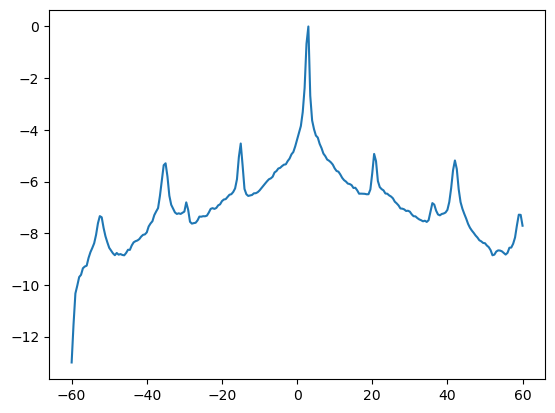

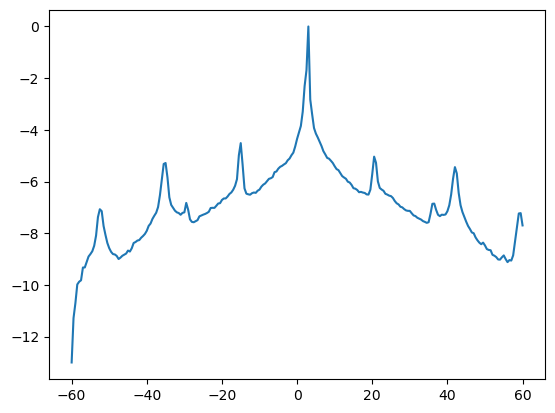

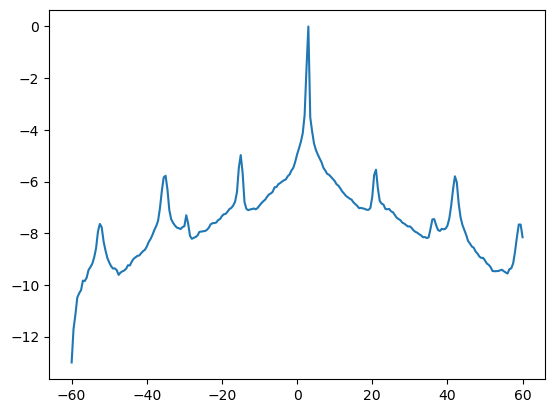

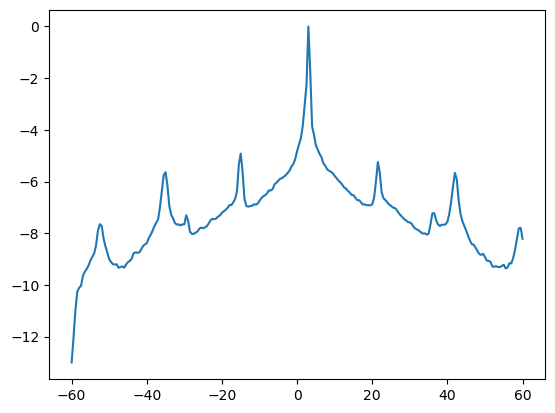

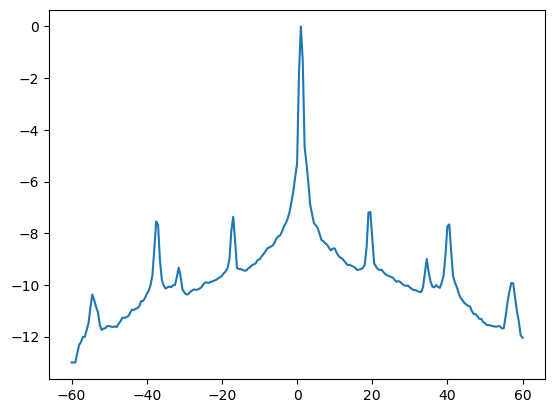

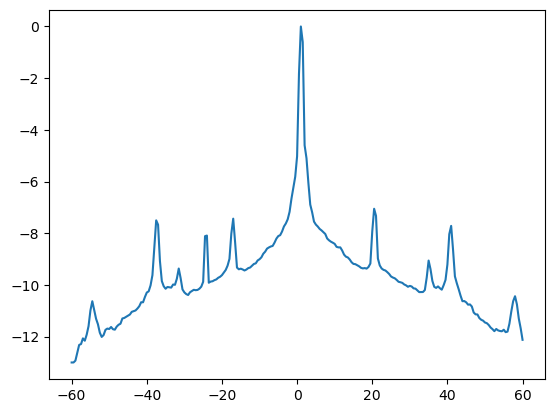

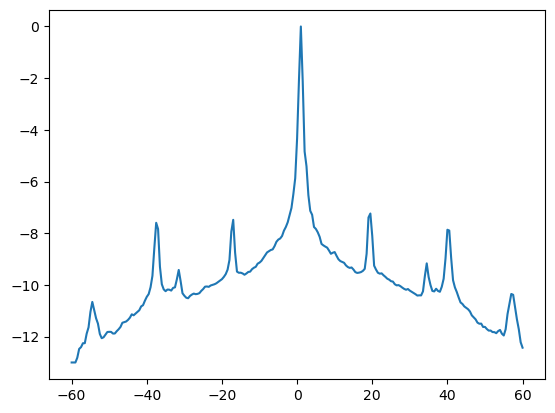

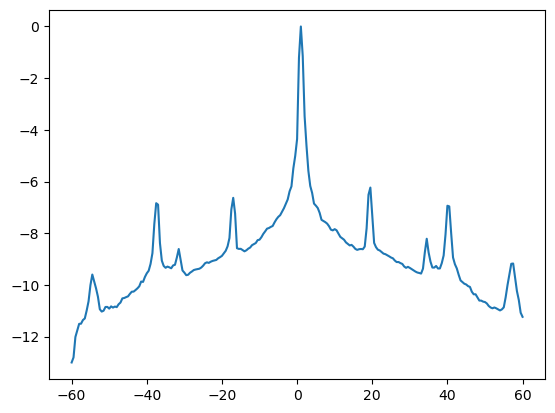

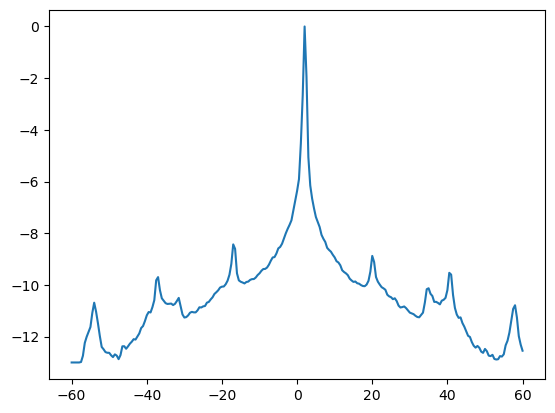

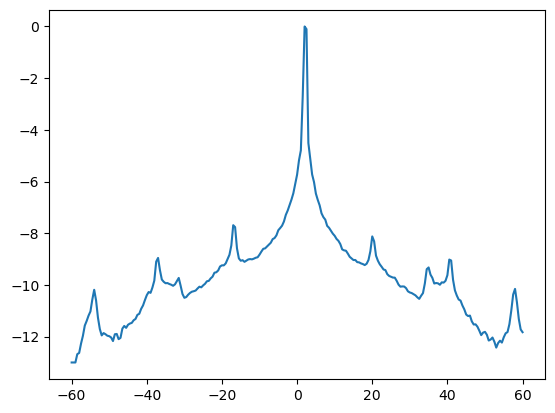

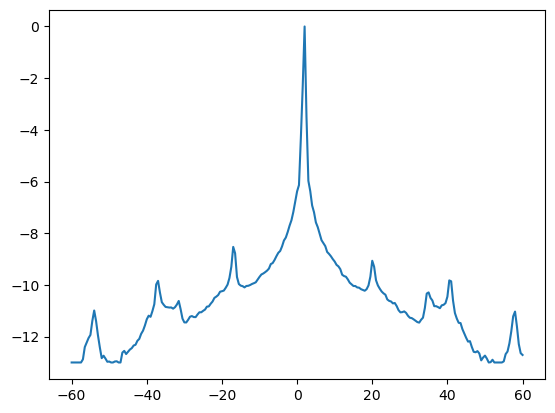

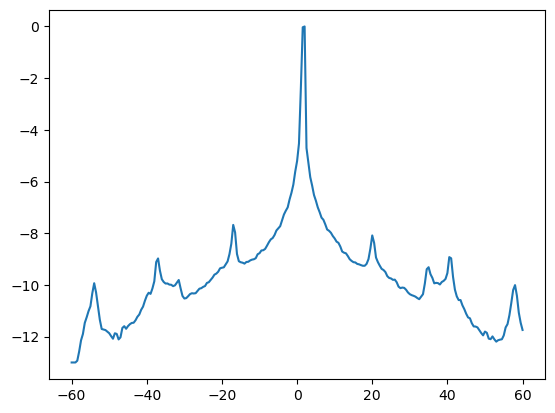

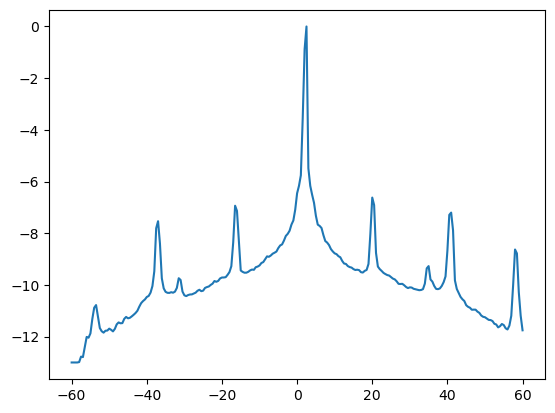

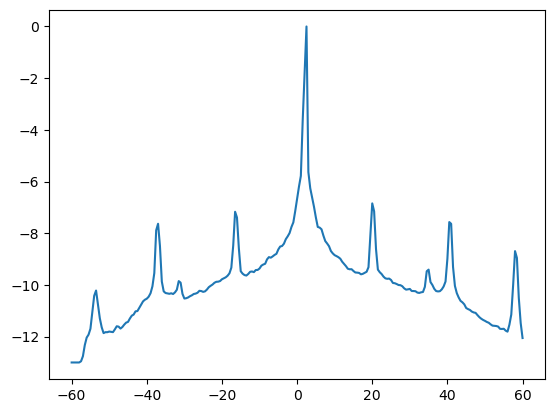

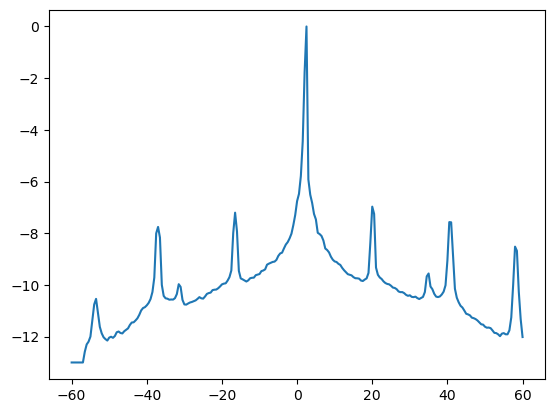

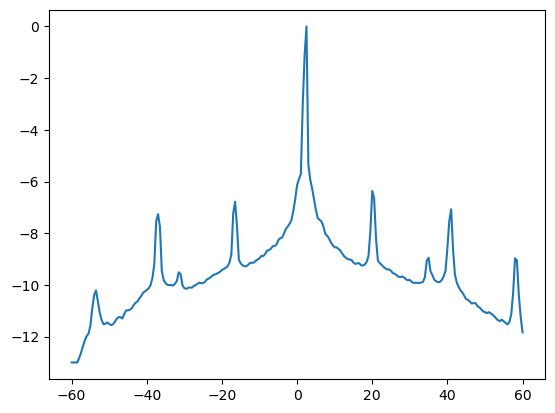

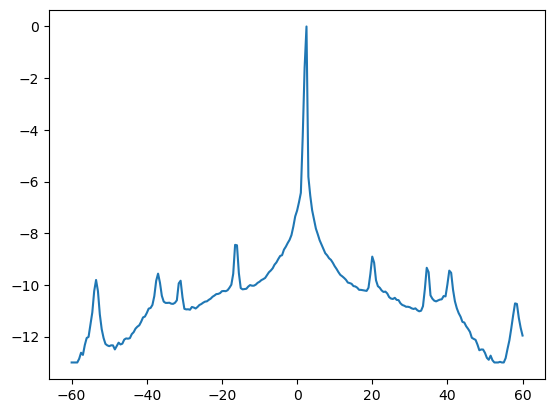

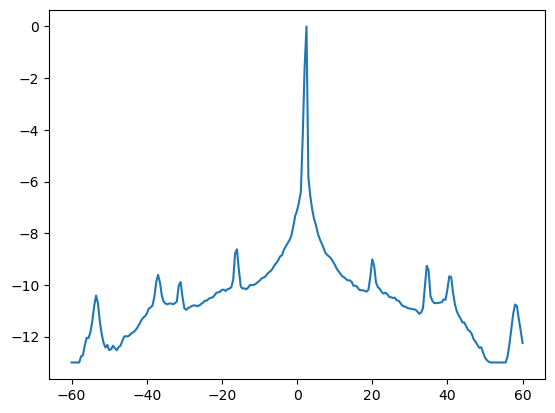

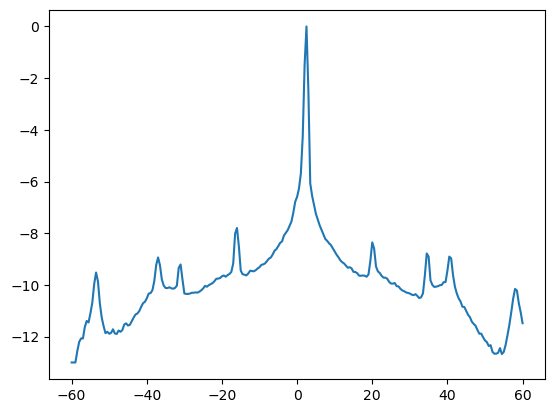

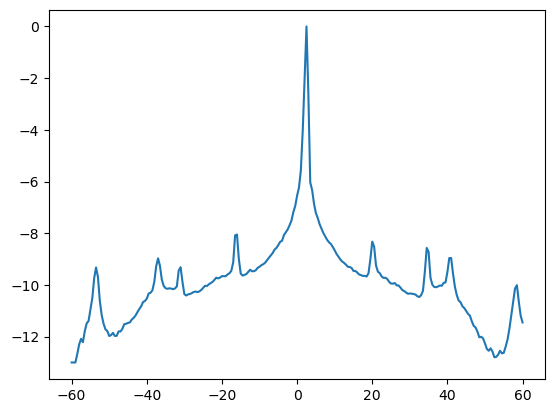

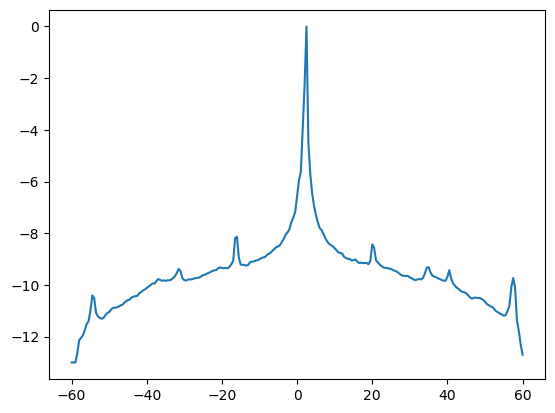

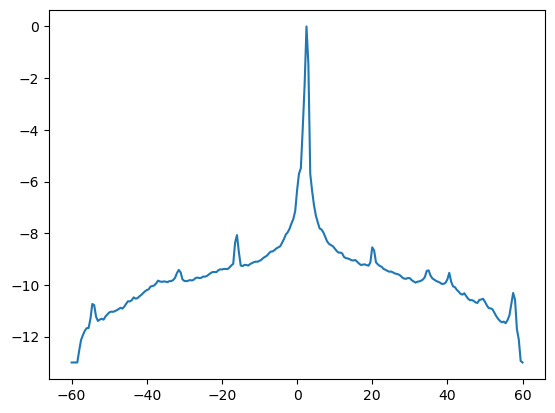

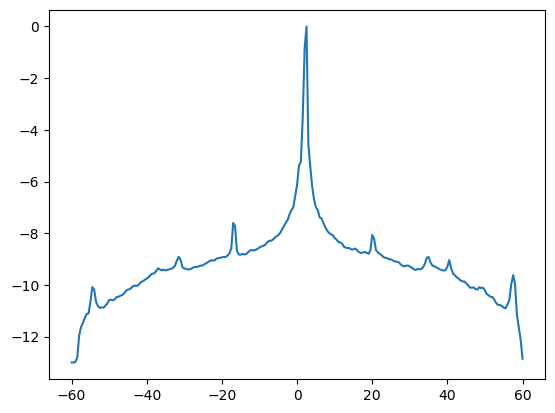

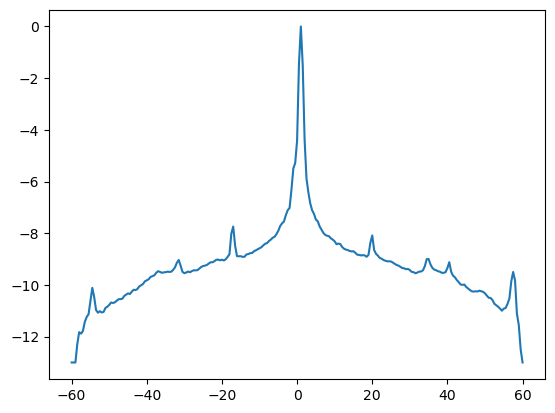

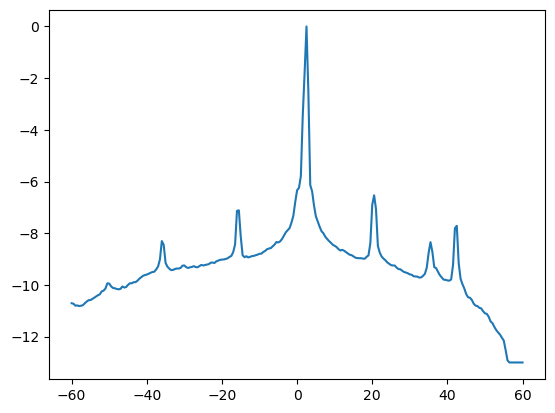

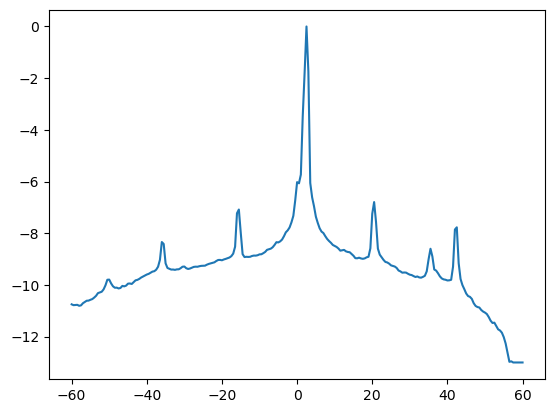

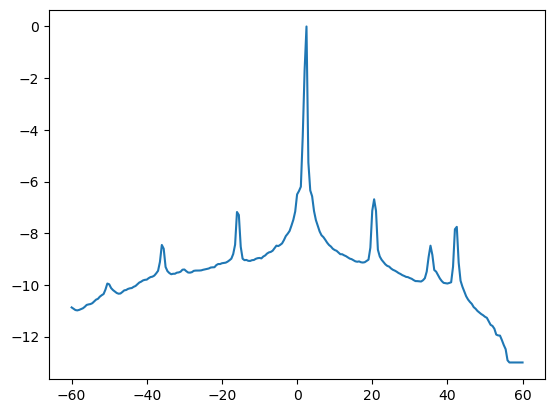

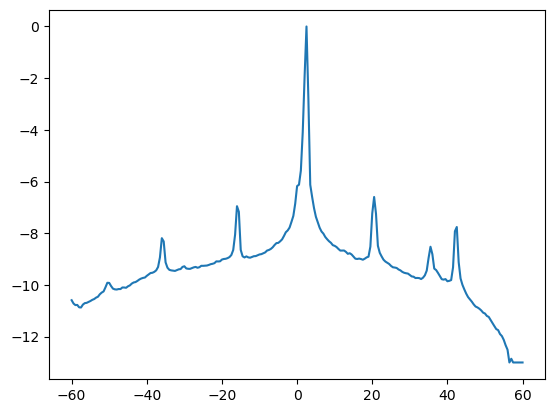

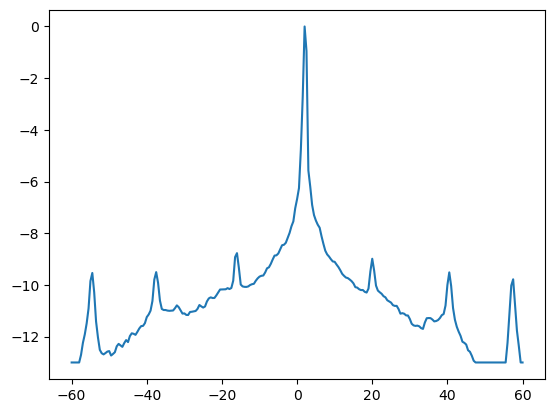

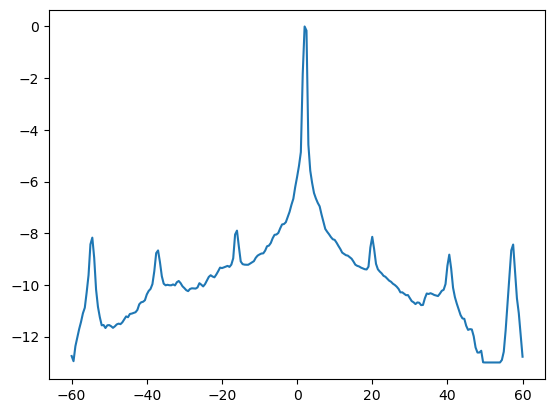

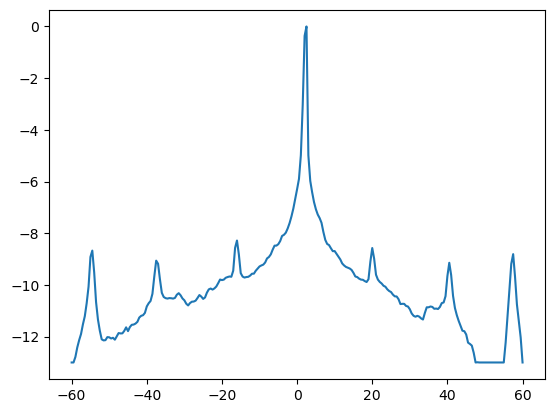

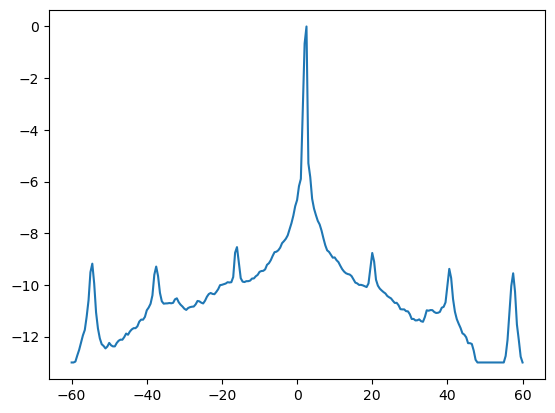

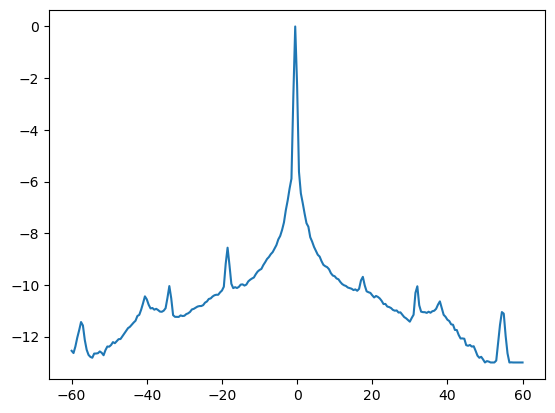

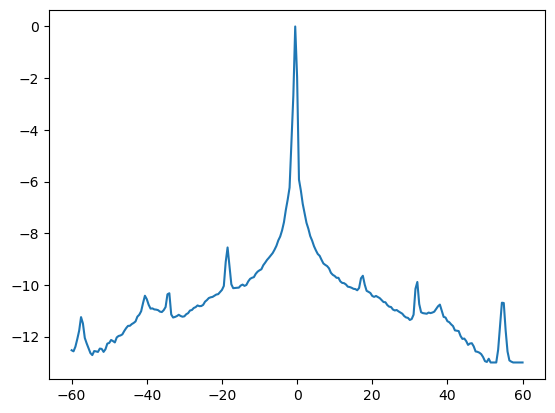

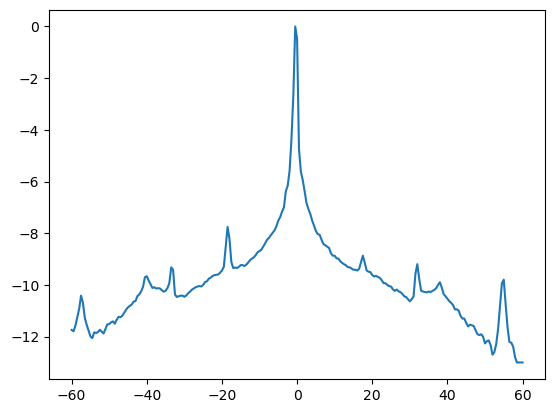

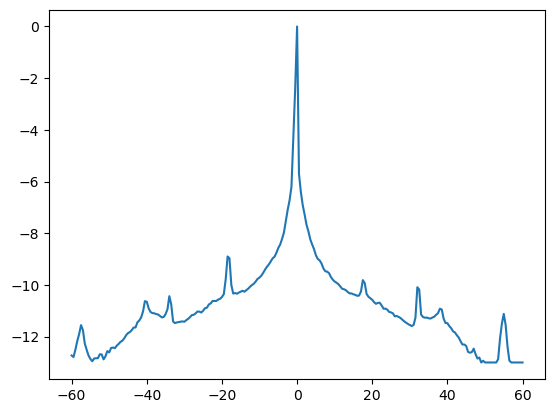

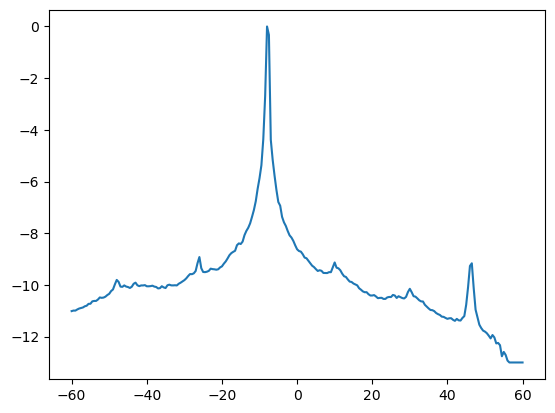

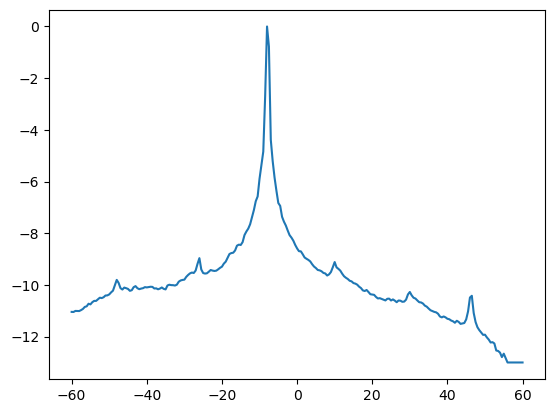

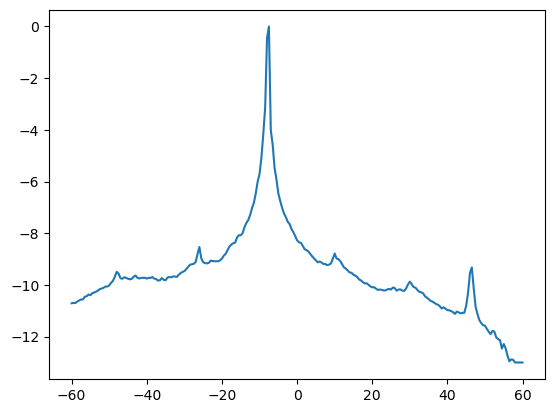

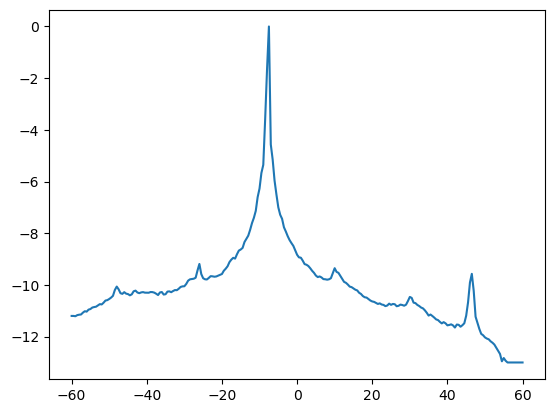

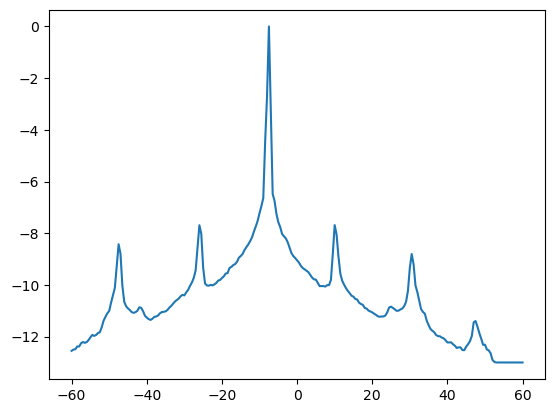

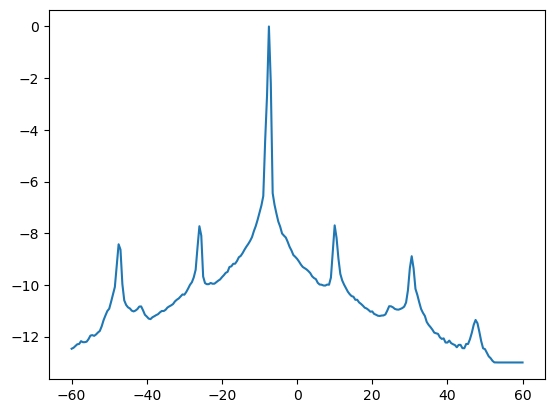

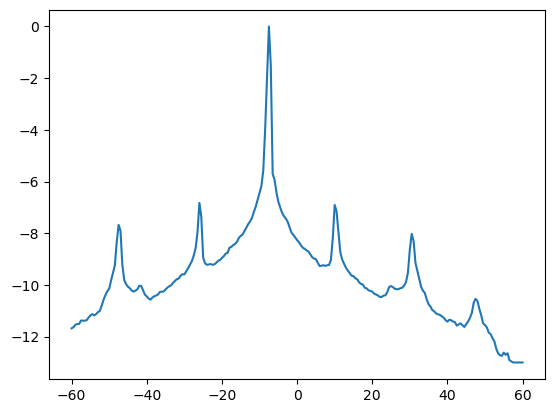

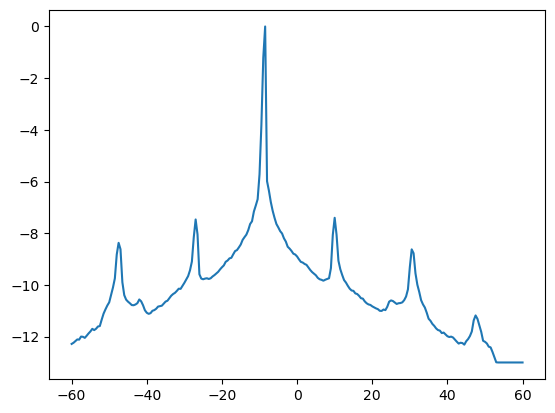

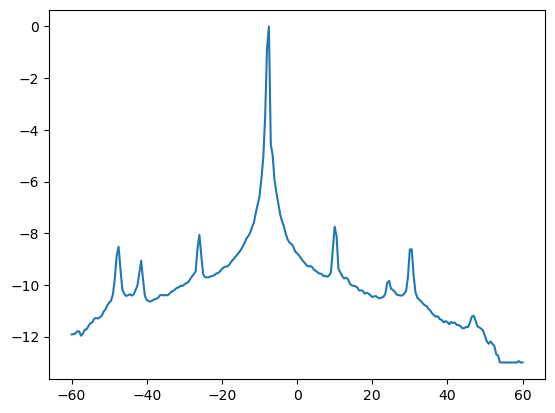

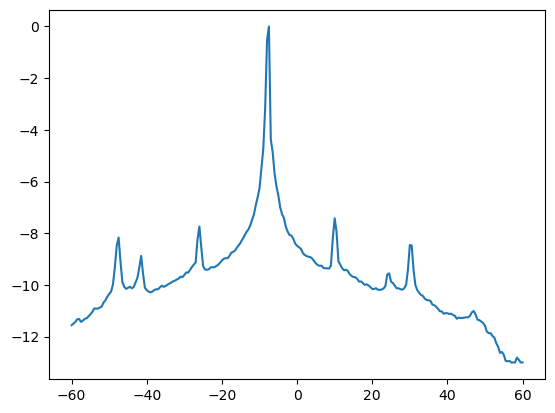

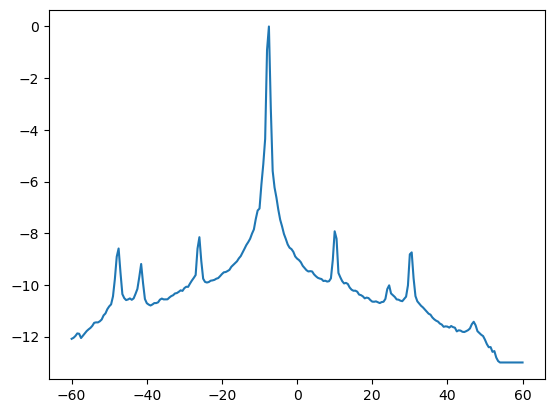

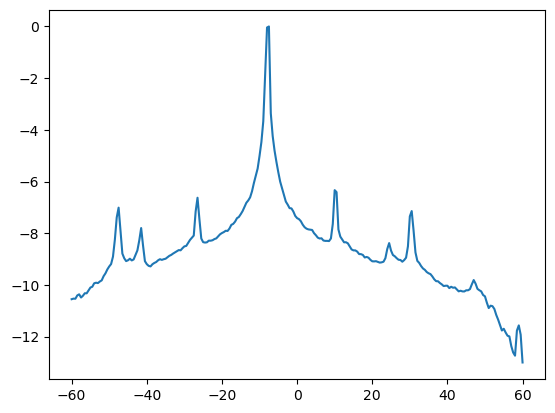

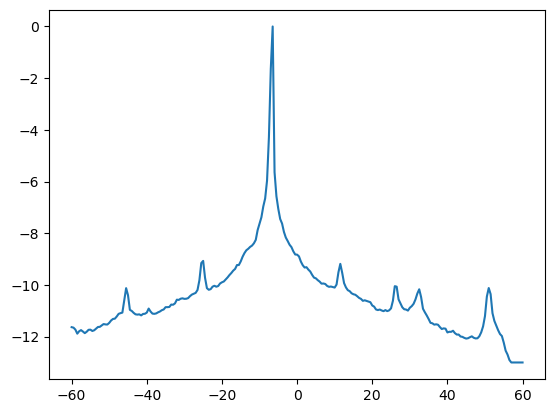

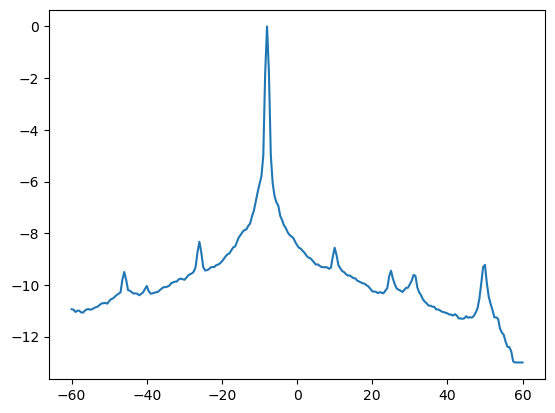

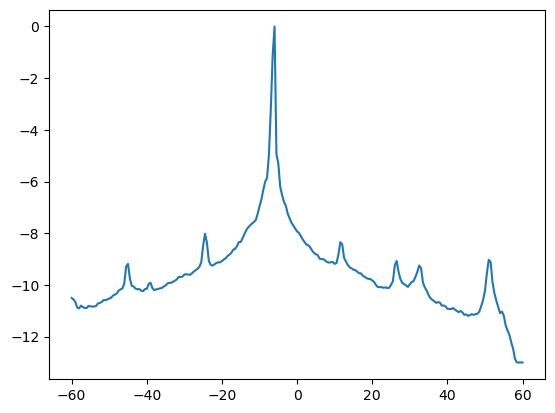

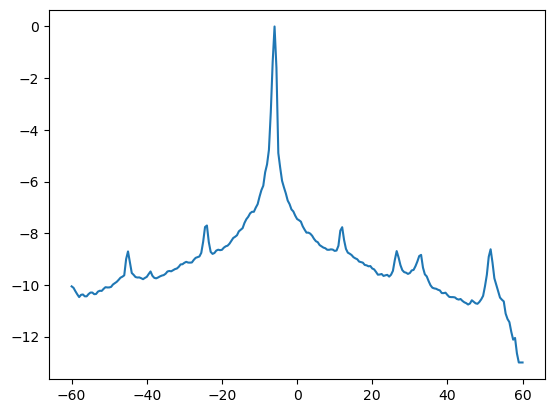

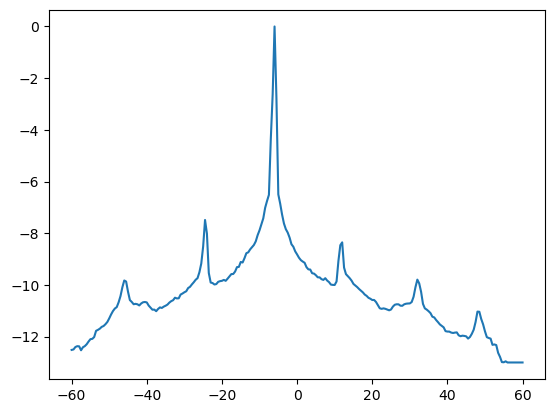

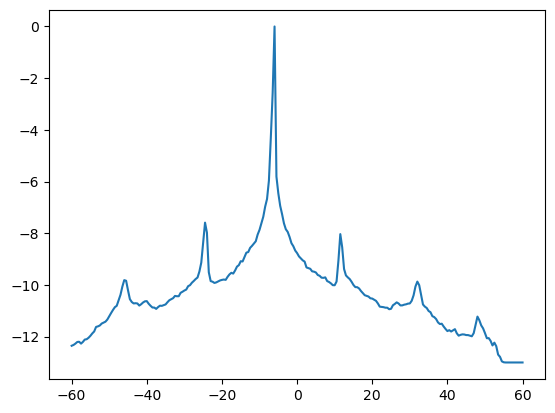

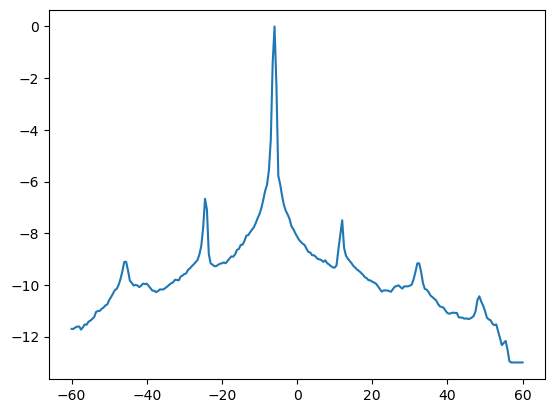

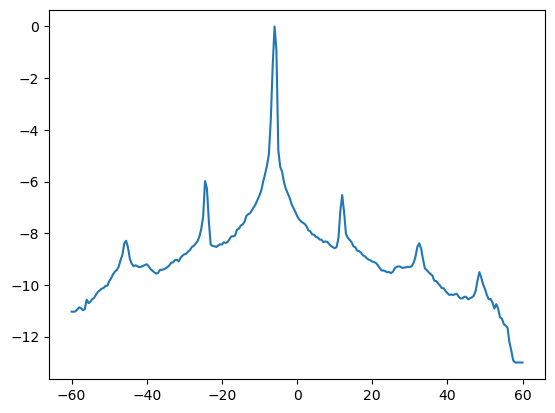

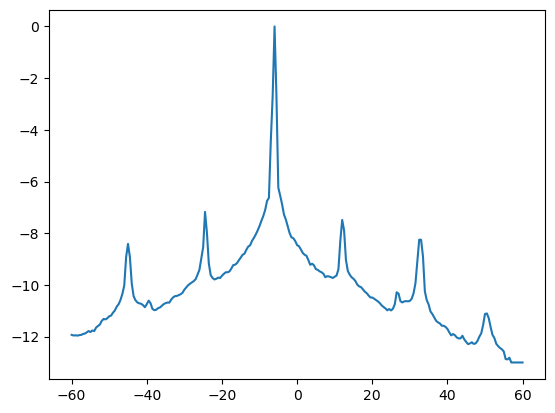

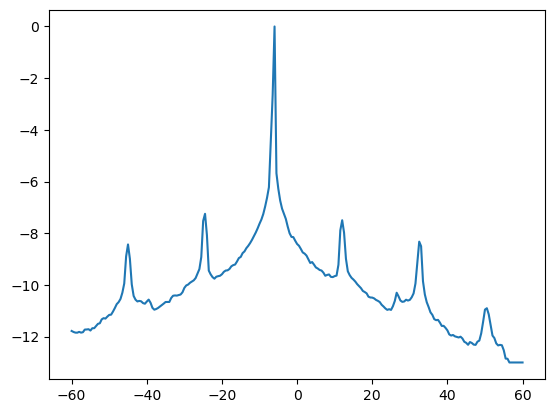

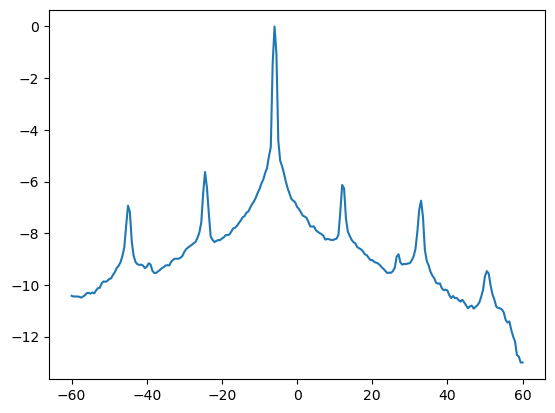

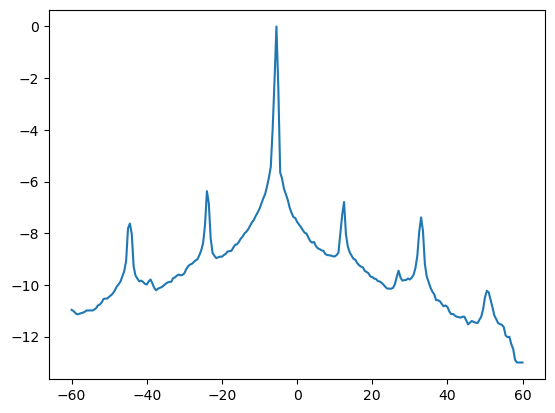

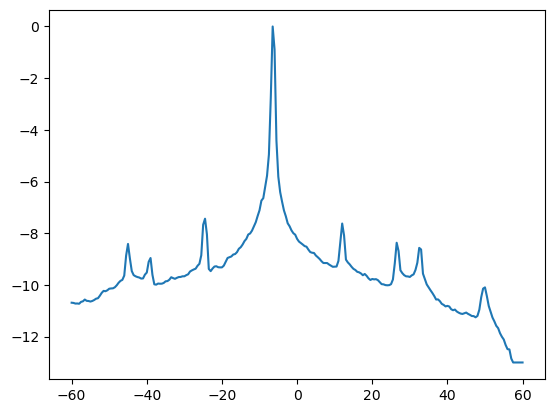

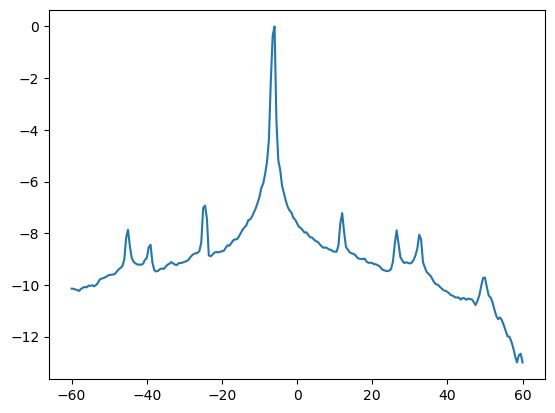

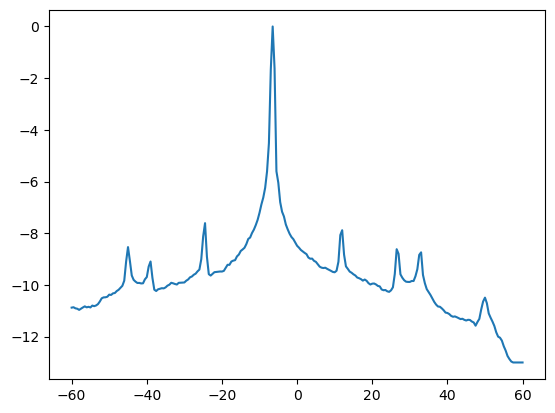

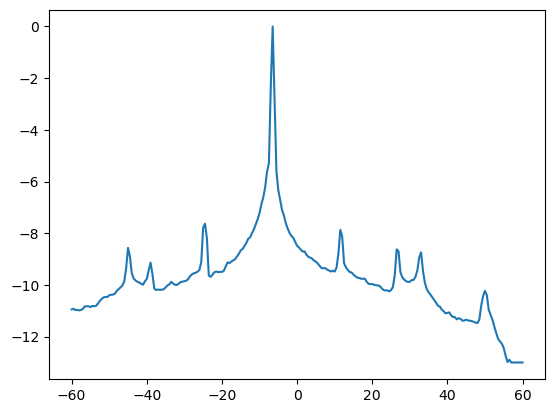

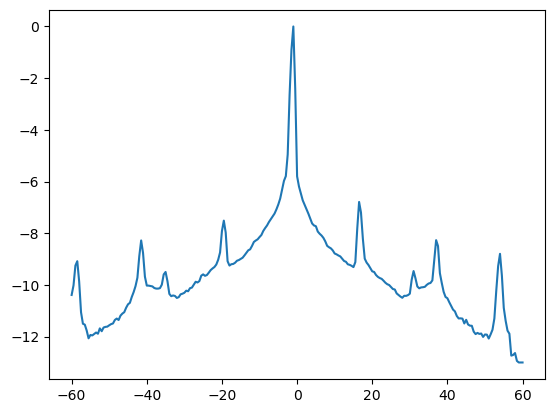

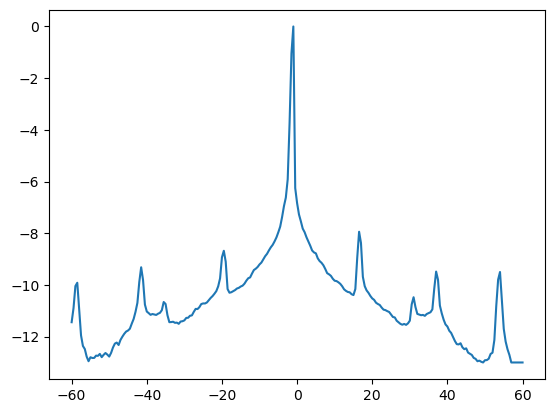

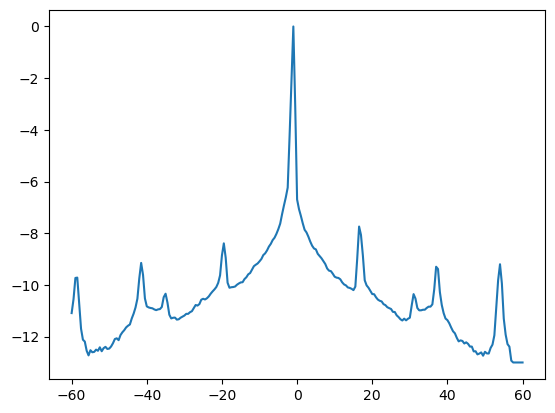

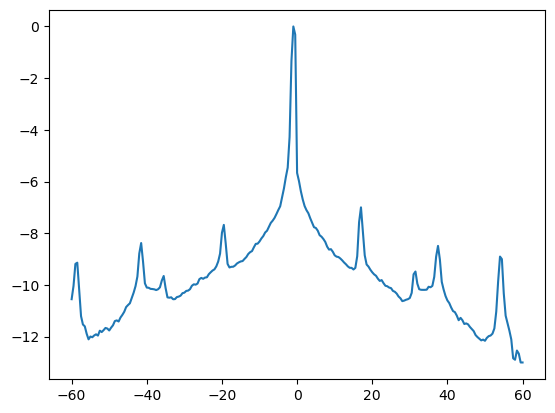

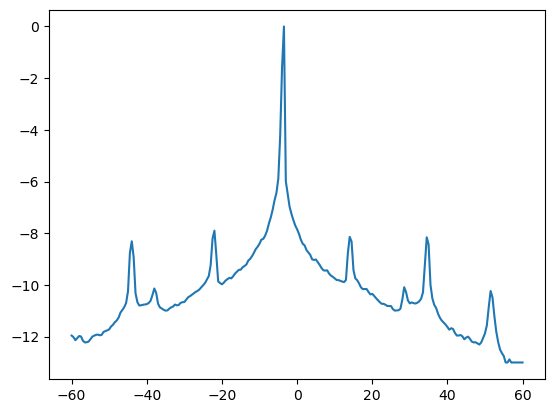

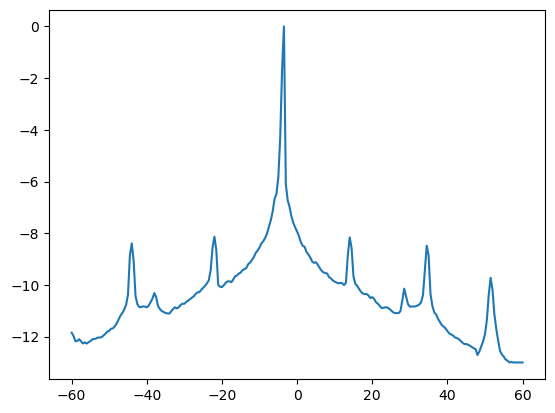

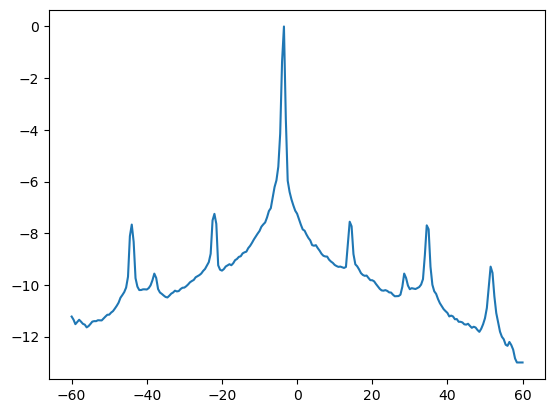

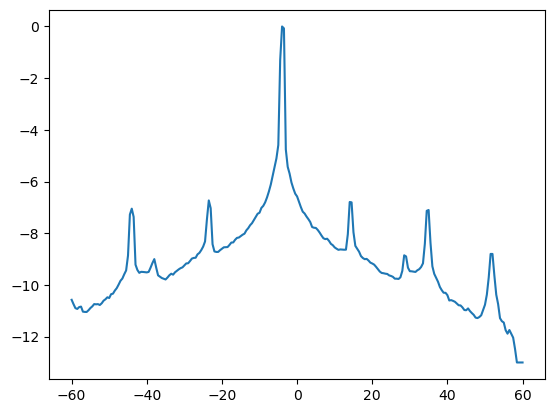

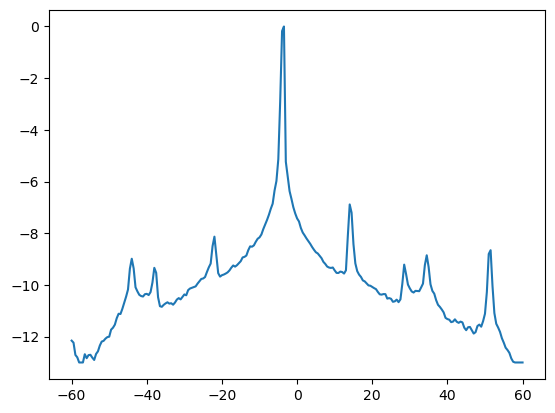

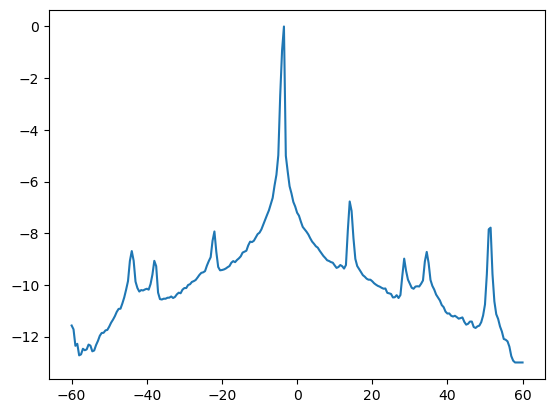

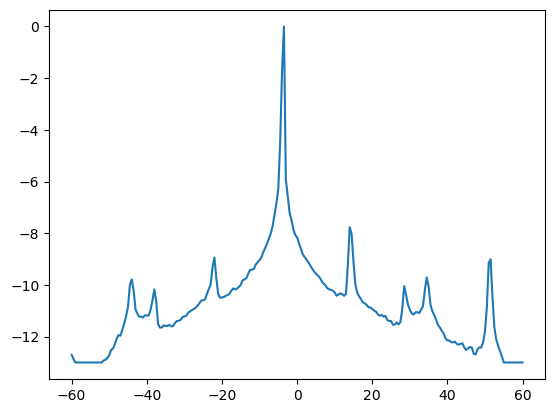

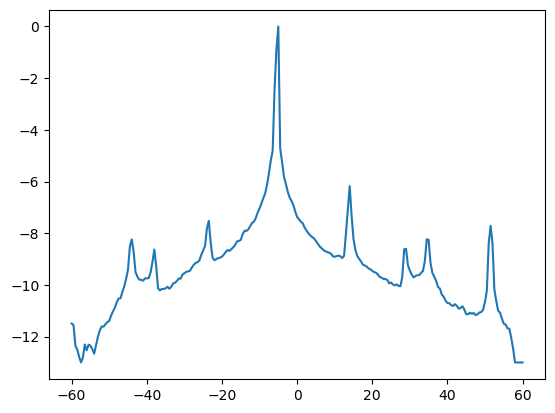

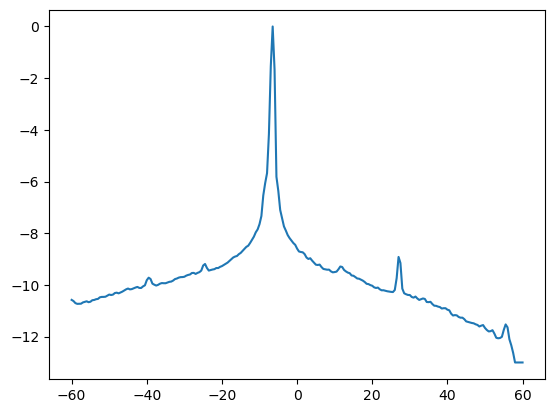

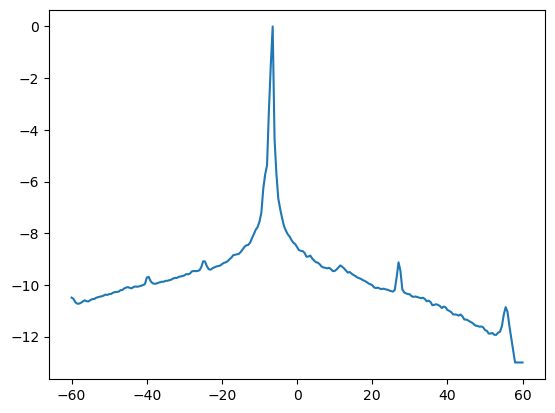

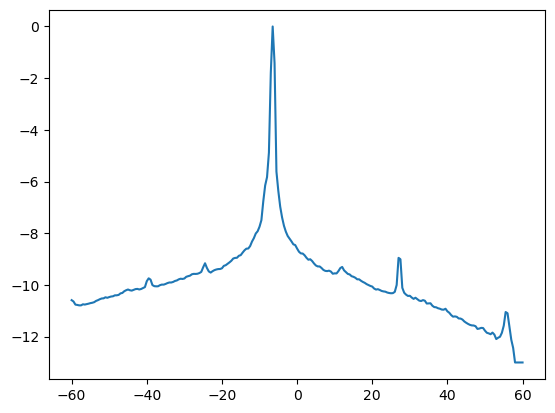

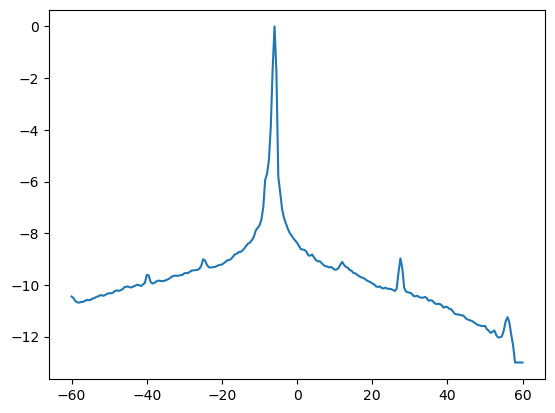

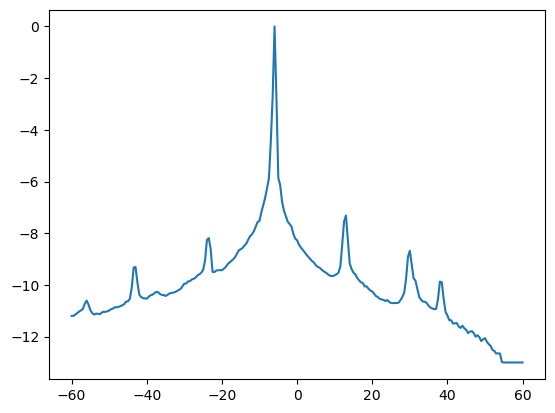

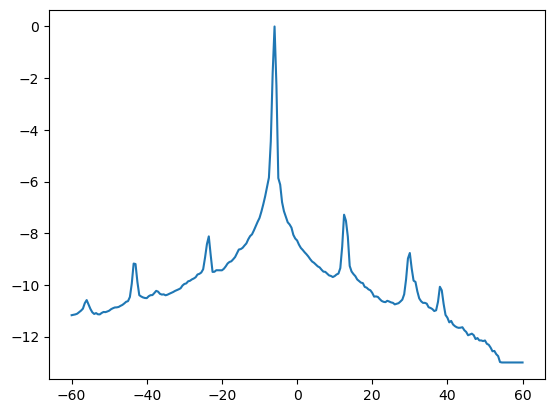

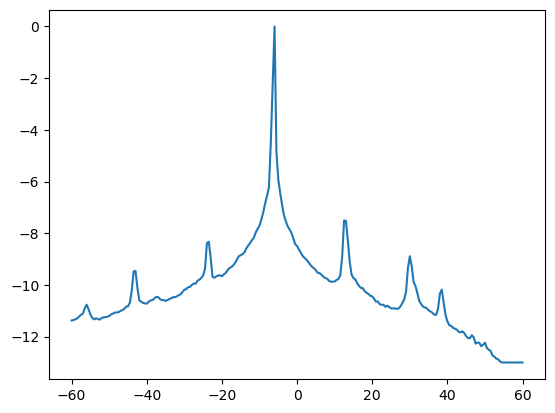

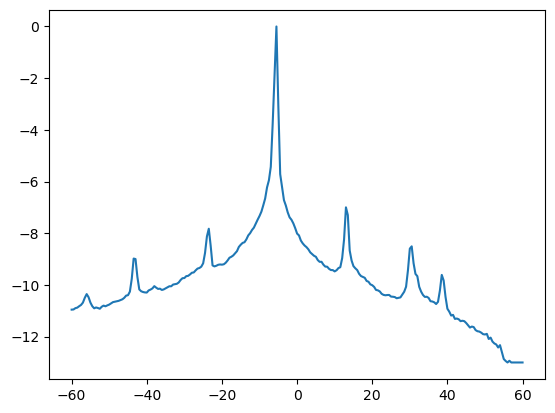

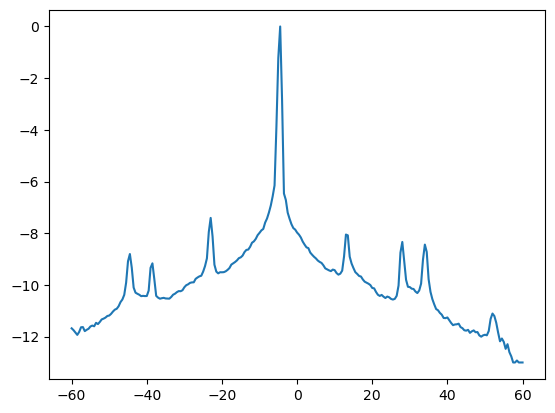

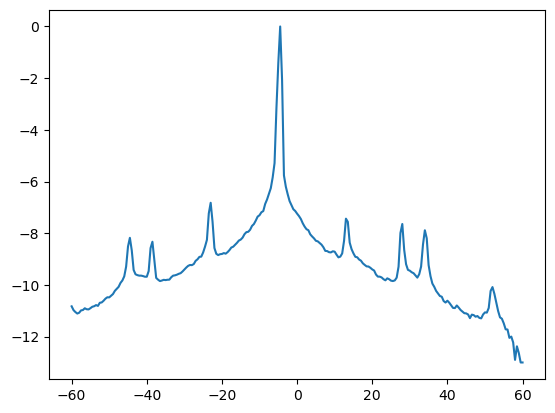

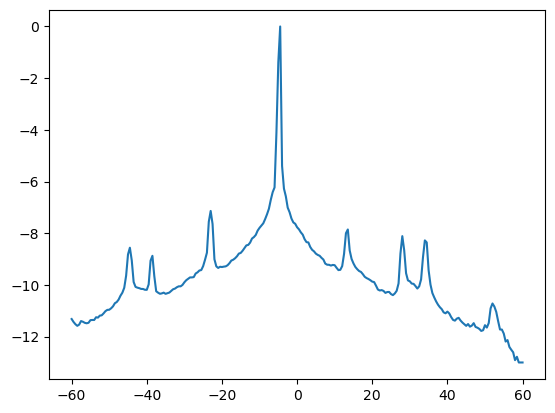

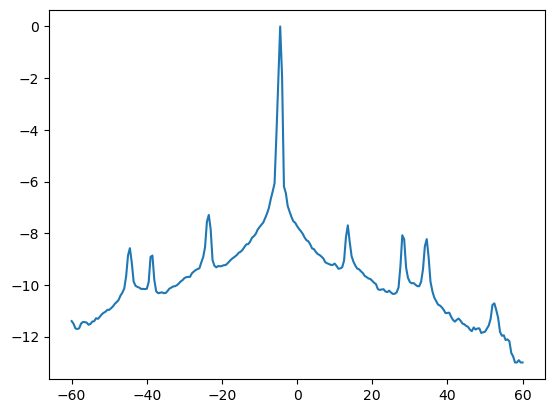

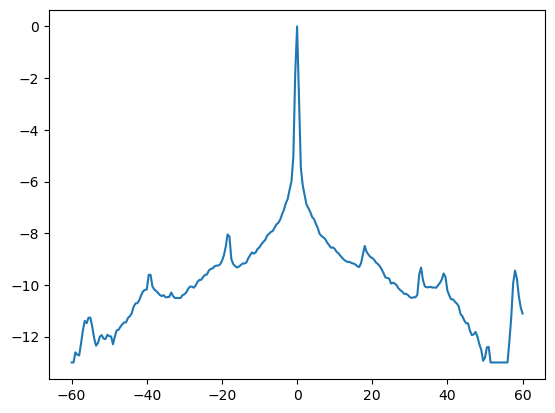

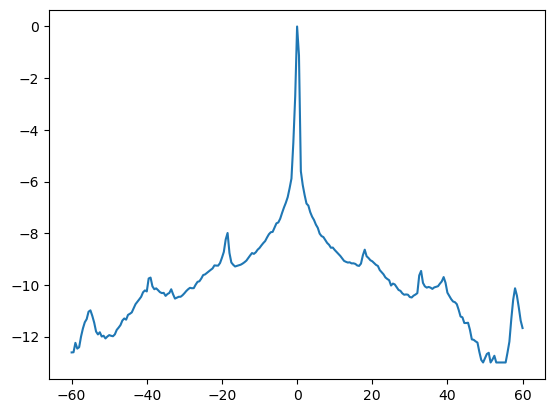

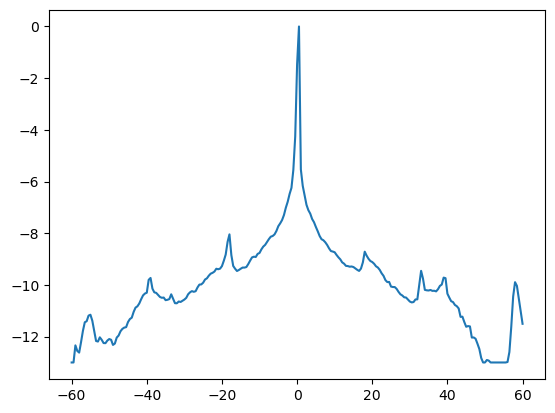

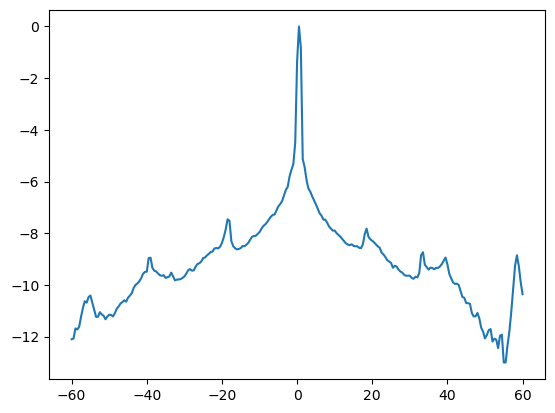

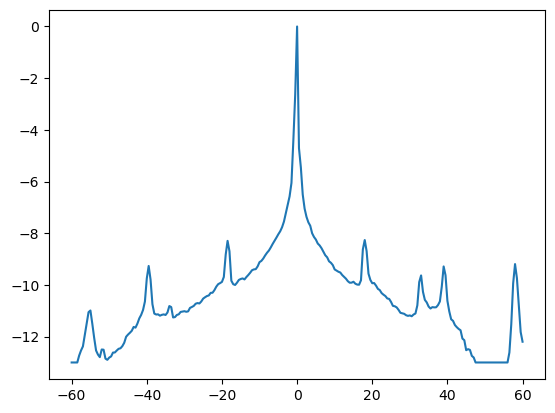

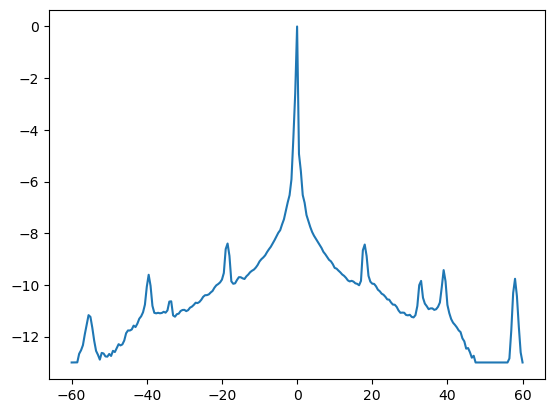

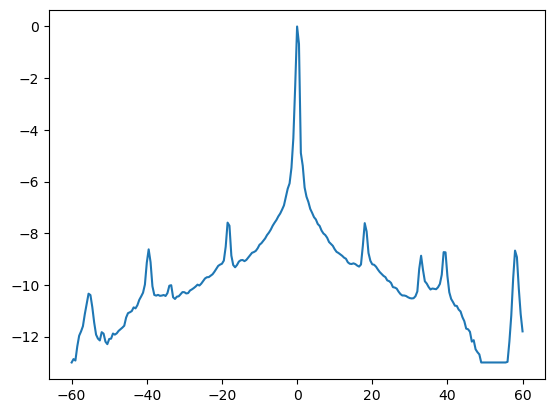

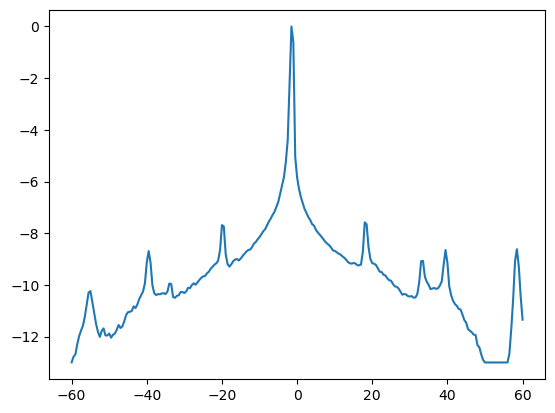

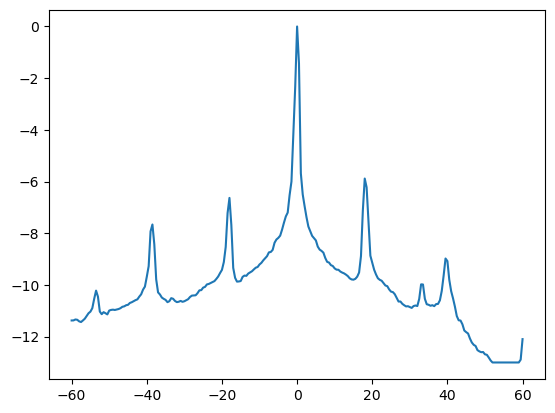

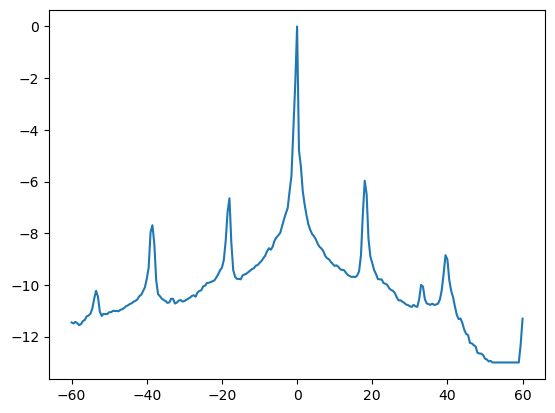

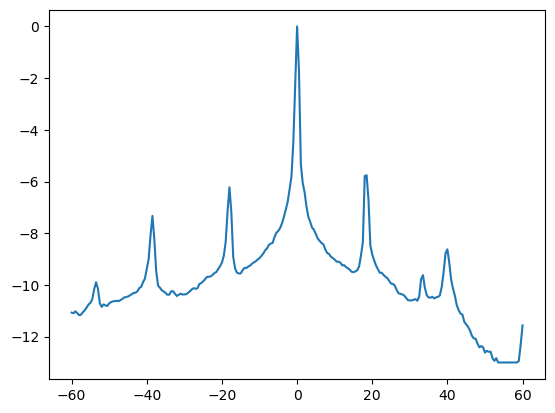

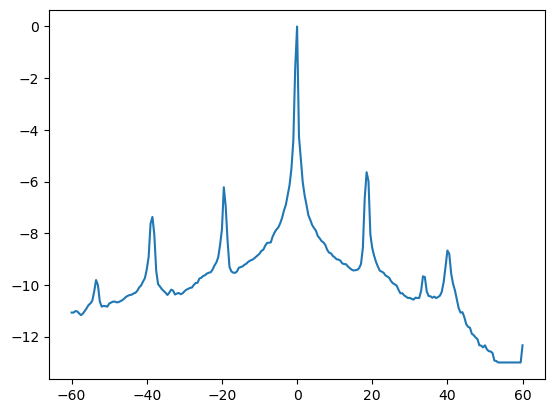

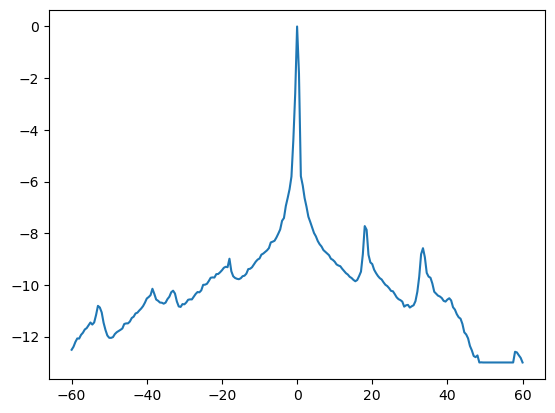

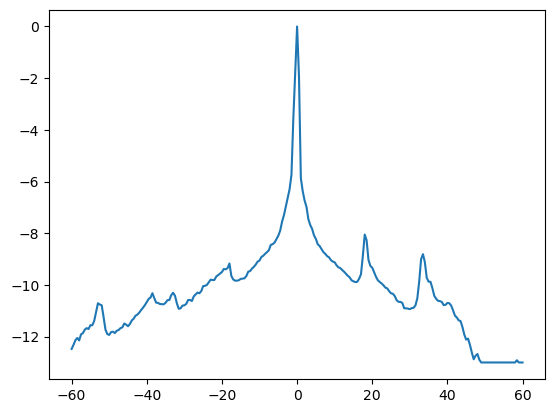

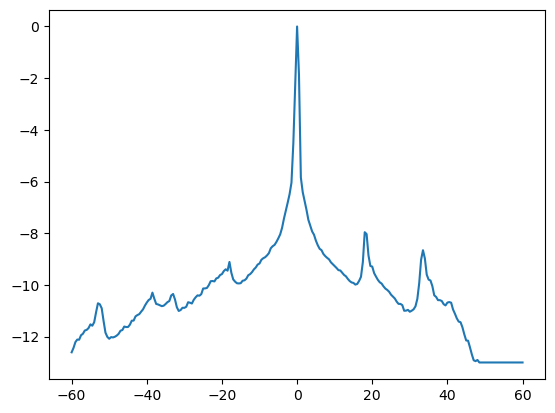

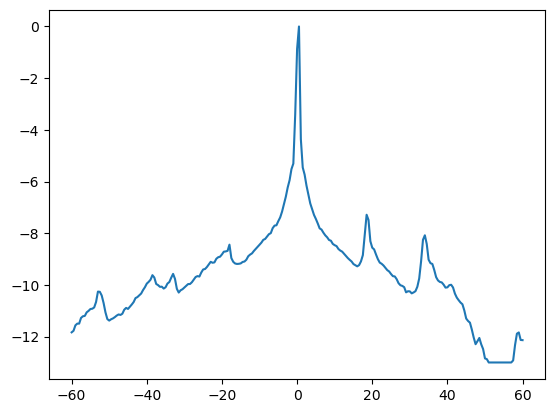

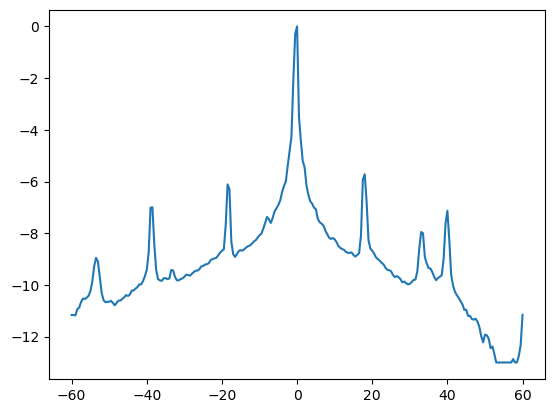

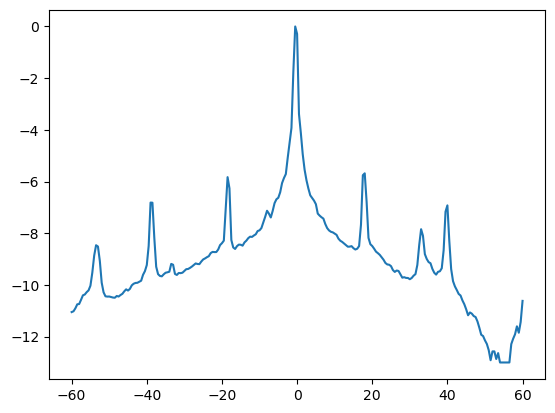

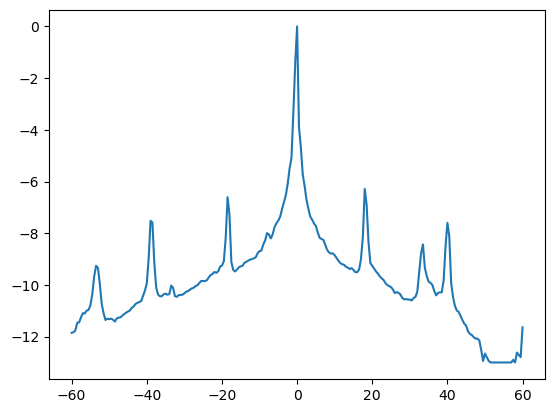

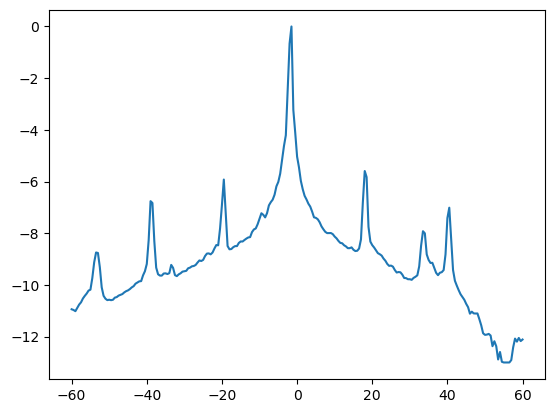

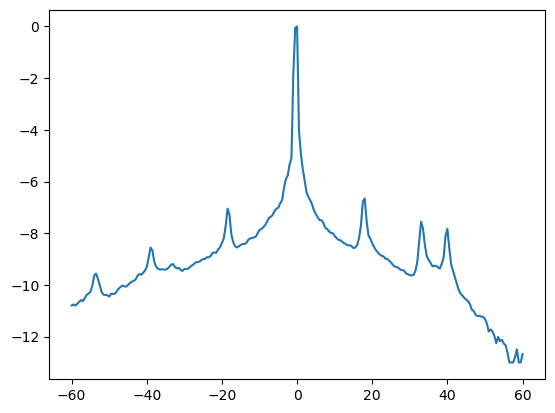

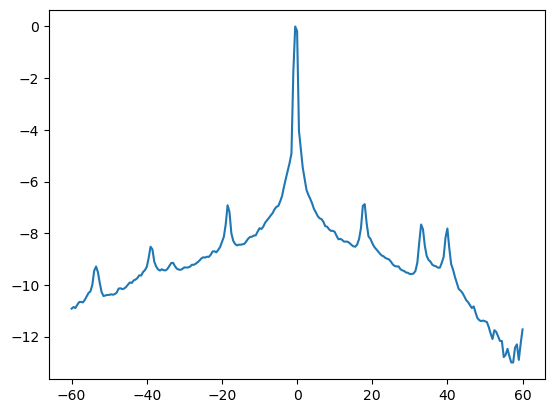

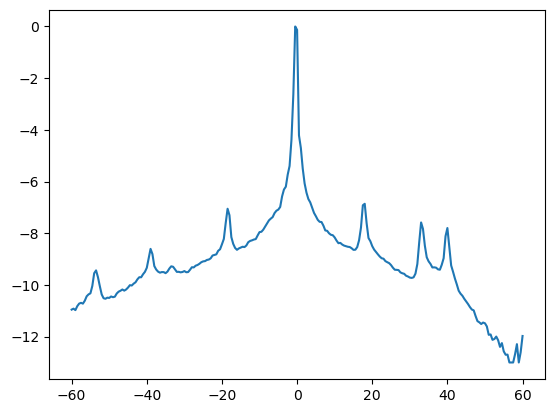

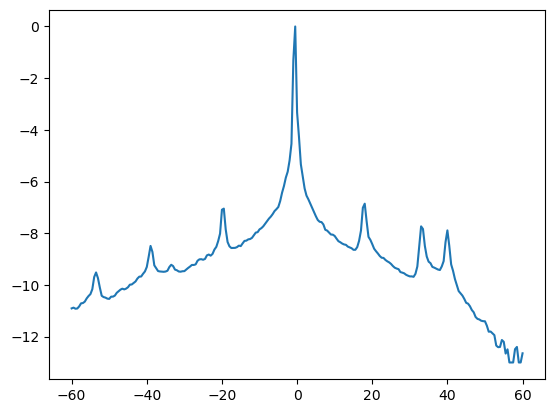

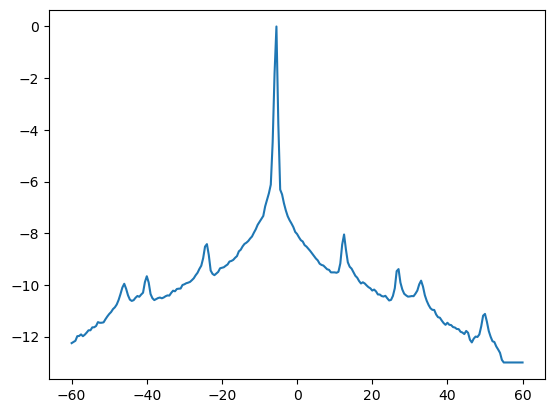

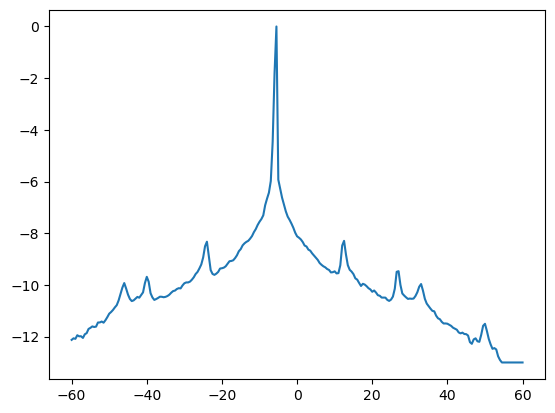

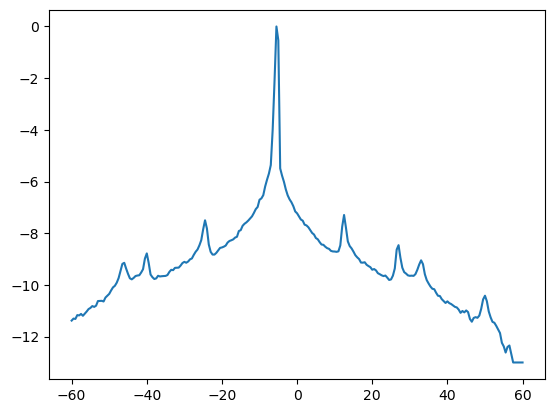

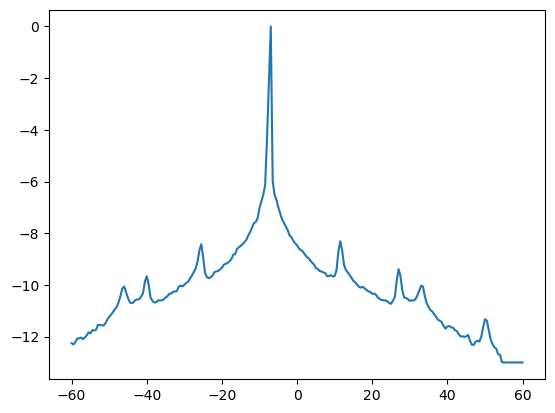

In [ ]:
from scipy.signal import find_peaks
from pybaselines import Baseline
lam_stiff=20000

outputs['polarization_shift']=[]
outputs['polarization_distance']=[]
outputs['stokes_data']=[]
input_pols=np.array([[0,1,0],[0,-1,0],[0,0,1],[0,0,-1]]) # 45 degree, -45 degree, LCP, RCP
for idx in range(len(outputs['rag'])):
    profiles=[]
    for pol in ['pos_45','neg_45','lcp','rcp']:
        profiles.append([]) # placeholder for each polarization
        r=outputs['ridx'][idx]
        c=outputs['cidx'][idx]
        path=fr"/mnt/c/Users/Jet/Documents/PhD Data/PANI/022526_r{r}_c{c}/022526_r{r}_c{c}_normal_incidence{pol}.csv"
        df=pd.read_csv(path)
        for adx in range(len(df)):
            profiles[-1].append(get_stokes(df, adx))
    profiles=np.array(profiles) # shape: (4, angle, stokes)
    outputs['stokes_data'].append(profiles)
    # Calculate mean flanking peak retardance
    shift=[]
    shift_linear=[]
    for p in range(4):
        y=profiles[p,:,0] 
        y=(y - np.min(y)) / (np.max(y) - np.min(y)+eps)
        y=np.log(y+eps)
        y[y<-13]=-13
        plt.plot(np.linspace(-60,60,len(y)), y)
        plt.show()
        baseline_fitter=Baseline(x_data=np.linspace(-60,60,len(y)))
        stiff_baseline=baseline_fitter.arpls(y, lam=lam_stiff)[0]
        y-=stiff_baseline
        peaks, properties = find_peaks(y,width=.1,prominence=0.1)
        
        if len(peaks)==0:
            print(f"Warning: No peaks found for Row {outputs['ridx'][idx]}, Column {outputs['cidx'][idx]}, Polarization {pol}. Setting shift to 0.")
            outputs['polarization_shift'].append(0)
        else:
            val=peaks[profiles[p,peaks,0]==np.max(profiles[p,peaks,0])][0]
            cidx=np.where(peaks==val)[0][0]
            l_pidx=peaks[cidx-1]
            r_pidx=peaks[cidx+1]
            l_peak_angle=np.abs(profiles[p,l_pidx,1:])
            r_peak_angle=np.abs(profiles[p,r_pidx,1:])
            l_peak_vector=l_peak_angle/(np.linalg.norm(l_peak_angle)+eps)
            r_peak_vector=r_peak_angle/(np.linalg.norm(r_peak_angle)+eps)
            shift.append(np.arccos(np.clip(np.dot(l_peak_vector, input_pols[p])+np.dot(r_peak_vector, input_pols[p])/2, -1.0, 1.0)))
            left_dist=l_peak_angle-input_pols[p]
            right_dist=r_peak_angle-input_pols[p]
            left_dist=left_dist[0]**2+left_dist[1]**2+left_dist[2]**2
            right_dist=right_dist[0]**2+right_dist[1]**2+right_dist[2]**2
            shift_linear.append((np.sqrt(left_dist)+np.sqrt(right_dist))/2)
    outputs['polarization_shift'].append(shift)
    outputs['polarization_distance'].append(shift_linear)


In [ ]:
import pickle 

with open('/mnt/c/Users/Jet/Downloads/outputs_25000.pkl', 'wb') as f:
    pickle.dump(outputs, f)

In [ ]:
import pickle

with open(r"/mnt/c/Users/Jet/Documents/PhD Data/PANI/020426/outputs_25000.pkl", 'rb') as f:
    outputs = pickle.load(f)

# verify
print(list(outputs.keys()))
print(f"Number of sites: {len(outputs['rag'])}")

In [7]:
import torch
from torch_geometric.data import Data

eps = 1e-10

def rag_to_pyg(rag, y=None):
    nodes    = list(rag.nodes())
    node_idx = {n: i for i, n in enumerate(nodes)}

    # node features: [area_norm, cos(mean_angle), sin(mean_angle)]
    node_feats = []
    for n in nodes:
        attr  = rag.nodes[n]
        area  = float(attr.get('area', 0.0))
        angle = float(attr.get('mean_angle', 0.0))
        hpos  = float(attr.get('horizontal_pos', 0.0))
        node_feats.append([area, np.cos(angle), np.sin(angle), hpos])
    x = torch.tensor(node_feats, dtype=torch.float)
    x[:, 0] = (x[:, 0] - x[:, 0].min()) / (x[:, 0].max() - x[:, 0].min() + eps)

    # edge features: [boundary_length_norm, angle_diff, horizontal diff]
    edge_index, edge_attr = [], []
    for u, v, attr in rag.edges(data=True):
        ui, vi = node_idx[u], node_idx[v]
        bl   = float(attr.get('boundary_length', 1.0))
        diff = float(attr.get('angle_diff', 0.0))
        
        # Compute horizontal dist
        cx_u  = rag.nodes[u].get('centroid', (0, 0))[0]
        cx_v  = rag.nodes[v].get('centroid', (0, 0))[0]
        hdist = abs(cx_u - cx_v)
        
        edge_index += [[ui, vi], [vi, ui]]
        edge_attr  += [[bl, diff, hdist], [bl, diff, hdist]]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)
    if edge_attr.shape[0] > 0:
        edge_attr[:, 0] = (edge_attr[:, 0] - edge_attr[:, 0].min()) / \
                          (edge_attr[:, 0].max() - edge_attr[:, 0].min() + eps)
        
        edge_attr[:, 2] = (edge_attr[:, 2] - edge_attr[:, 2].min()) / \
                          (edge_attr[:, 2].max() - edge_attr[:, 2].min() + eps)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    if y is not None:
        data.y = torch.tensor([[float(y)]], dtype=torch.float)
    return data


# --- build dataset ---
# y = mean polarization_shift across the 4 polarizations per site
dataset = []
for i in range(len(outputs['rag'])):
    rag    = outputs['rag'][i]
    shifts = outputs['polarization_shift'][i]
    y      = np.mean(shifts) if len(shifts) > 0 else None
    data   = rag_to_pyg(rag, y=y)
    data.ridx = outputs['ridx'][i]
    data.cidx = outputs['cidx'][i]
    dataset.append(data)

print(f"Dataset: {len(dataset)} graphs")
print(f"Example: {dataset[0]}")
print(f"x:          {dataset[0].x.shape}  → (nodes, features)")
print(f"edge_index: {dataset[0].edge_index.shape}")
print(f"edge_attr:  {dataset[0].edge_attr.shape}")
print(f"y:          {dataset[0].y}")

Dataset: 29 graphs
Example: Data(x=[68, 4], edge_index=[2, 356], edge_attr=[356, 3], y=[1, 1], ridx=1, cidx=2)
x:          torch.Size([68, 4])  → (nodes, features)
edge_index: torch.Size([2, 356])
edge_attr:  torch.Size([356, 3])
y:          tensor([[1.5390]])


In [8]:
rag = outputs['rag'][0]  # first site
r = outputs['ridx'][0]
c = outputs['cidx'][0]

print(f"=== Site r{r}_c{c} ===")
print(f"Nodes: {rag.number_of_nodes()} | Edges: {rag.number_of_edges()}")

print("\n--- NODE FEATURES ---")
for node_id, attrs in rag.nodes(data=True):
    print(f"Node {node_id}:")
    print(f"  area:           {attrs.get('area')}")
    print(f"  mean_angle:     {attrs.get('mean_angle'):.4f} rad  ({np.degrees(attrs.get('mean_angle', 0)):.2f}°)")
    print(f"  horizontal_pos: {attrs.get('horizontal_pos'):.4f}")
    print(f"  centroid:       {attrs.get('centroid')}")

print("\n--- EDGE FEATURES ---")
for u, v, attrs in rag.edges(data=True):
    print(f"Edge ({u}, {v}):")
    print(f"  boundary_length:  {attrs.get('boundary_length')}")
    print(f"  angle_diff:       {attrs.get('angle_diff'):.4f} rad  ({np.degrees(attrs.get('angle_diff', 0)):.2f}°)")

=== Site r1_c2 ===
Nodes: 68 | Edges: 178

--- NODE FEATURES ---
Node 1:
  area:           28457.0
  mean_angle:     0.0384 rad  (2.20°)
  horizontal_pos: 0.0266
  centroid:       (np.float64(73.09762097199282), np.float64(121.46754752784904))
Node 2:
  area:           158980.0
  mean_angle:     0.0341 rad  (1.95°)
  horizontal_pos: 0.1002
  centroid:       (np.float64(275.6712165052208), np.float64(311.1697257516669))
Node 3:
  area:           31610.0
  mean_angle:     0.9727 rad  (55.73°)
  horizontal_pos: 0.1483
  centroid:       (np.float64(408.14783296425185), np.float64(95.61145207212907))
Node 4:
  area:           123435.0
  mean_angle:     0.2035 rad  (11.66°)
  horizontal_pos: 0.2602
  centroid:       (np.float64(716.1441001336736), np.float64(207.1447968566452))
Node 5:
  area:           38874.0
  mean_angle:     0.9112 rad  (52.21°)
  horizontal_pos: 0.3261
  centroid:       (np.float64(897.3922673252046), np.float64(49.91261511550136))
Node 6:
  area:           84645.0
  me

In [9]:
import pandas as pd

# nodes table
node_data = []
for node_id, attrs in rag.nodes(data=True):
    node_data.append({
        'node_id':        node_id,
        'area':           attrs.get('area'),
        'mean_angle_deg': round(np.degrees(attrs.get('mean_angle', 0)), 2),
        'horizontal_pos': round(attrs.get('horizontal_pos', 0), 4),
    })
print("NODES:")
print(pd.DataFrame(node_data).to_string(index=False))

# edges table
edge_data = []
for u, v, attrs in rag.edges(data=True):
    edge_data.append({
        'u':               u,
        'v':               v,
        'boundary_length': attrs.get('boundary_length'),
        'angle_diff_deg':  round(np.degrees(attrs.get('angle_diff', 0)), 2),
    })
print("\nEDGES:")
print(pd.DataFrame(edge_data).to_string(index=False))

NODES:
 node_id     area  mean_angle_deg  horizontal_pos
       1  28457.0        2.200000          0.0266
       2 158980.0        1.950000          0.1002
       3  31610.0       55.730000          0.1483
       4 123435.0       11.660000          0.2602
       5  38874.0       52.209999          0.3261
       6  84645.0       22.740000          0.4877
       7  66239.0       56.820000          0.5988
       8  85554.0       56.389999          0.6234
       9  43225.0       56.950001          0.8137
      10  74244.0       46.709999          0.9457
      11 239291.0       49.529999          0.7253
      12  89003.0        6.930000          0.4347
      13  40837.0        2.120000          0.0279
      14  32280.0       43.490002          0.8567
      15 111445.0       45.130001          0.8736
      16  26514.0       13.490000          0.2343
      17 111242.0        6.520000          0.3578
      18  92521.0       16.330000          0.2141
      19  78534.0       49.270000          

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class SiteGNN(nn.Module):
    def __init__(self):
        super().__init__()

        # --- message passing layers ---
        # in_dim=4: [area_norm, cos(angle), sin(angle), horizontal_pos]
        self.conv1 = GCNConv(in_channels=4,  out_channels=32)
        self.conv2 = GCNConv(in_channels=32, out_channels=32)

        # --- MLP head (same as regular NN) ---
        self.fc1 = nn.Linear(32, 16)
        self.fc2 = nn.Linear(16, 1)   # single scalar output

        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x, edge_index, batch):
        # --- message passing ---
        x = self.conv1(x, edge_index)   # (N_nodes, 32)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)   # (N_nodes, 32)
        x = F.relu(x)

        # --- pool all nodes into one vector per graph ---
        x = global_mean_pool(x, batch)  # (N_graphs, 32)

        # --- MLP head ---
        x = self.fc1(x)                 # (N_graphs, 16)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)                 # (N_graphs, 1)

        return x

model = SiteGNN()
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

SiteGNN(
  (conv1): GCNConv(4, 32)
  (conv2): GCNConv(32, 32)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Total parameters: 1761


Site 1/29 done | pred: 1.5310 | true: 1.5390
Site 2/29 done | pred: 1.4074 | true: 1.5469
Site 3/29 done | pred: 1.4503 | true: 1.5419
Site 4/29 done | pred: 1.5482 | true: 1.5404
Site 5/29 done | pred: 1.6068 | true: 1.5408
Site 6/29 done | pred: 1.5027 | true: 1.5563
Site 7/29 done | pred: 1.5092 | true: 1.5292
Site 8/29 done | pred: 1.5089 | true: 1.5370
Site 9/29 done | pred: 1.4888 | true: 1.5486
Site 10/29 done | pred: 1.4702 | true: 1.5790
Site 11/29 done | pred: 1.5621 | true: 1.5501
Site 12/29 done | pred: 1.4655 | true: 1.5354
Site 13/29 done | pred: 1.5427 | true: 1.5209
Site 14/29 done | pred: 1.5410 | true: 1.4935
Site 15/29 done | pred: 1.5609 | true: 1.5623
Site 16/29 done | pred: 1.4477 | true: 1.5490
Site 17/29 done | pred: 1.5851 | true: 1.5469
Site 18/29 done | pred: 1.4723 | true: 1.5611
Site 19/29 done | pred: 1.4394 | true: 1.5219
Site 20/29 done | pred: 1.4896 | true: 1.5708
Site 21/29 done | pred: 1.4707 | true: 1.5134
Site 22/29 done | pred: 1.4908 | true: 1.53

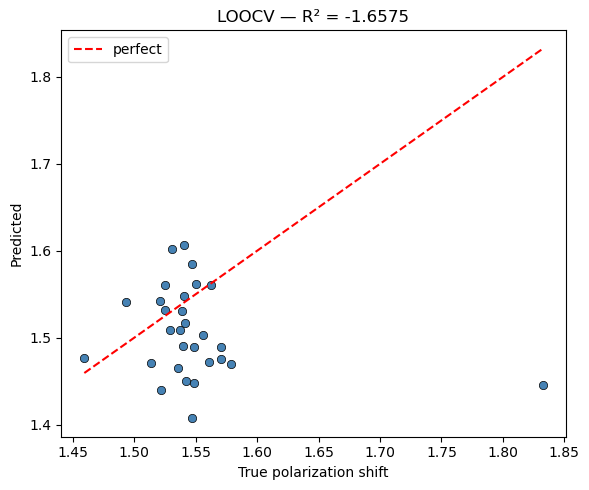

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

all_preds, all_targets = [], []

for i in range(len(dataset)):
    train_set = [dataset[j] for j in range(len(dataset)) if j != i]
    test_graph = dataset[i]

    train_loader = DataLoader(train_set, batch_size=8, shuffle=True)

    model = SiteGNN()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    for epoch in range(300):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = loss_fn(pred, batch.y)
            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        test_batch = DataLoader([test_graph], batch_size=1)
        for b in test_batch:
            pred = model(b.x, b.edge_index, b.batch)
            all_preds.append(pred.item())
            all_targets.append(b.y.item())

        print(f"Site {i+1}/{len(dataset)} done | pred: {all_preds[-1]:.4f} | true: {all_targets[-1]:.4f}")



# --- Results ---
all_preds = np.array(all_preds)
all_targes = np.array(all_targets)
r2 = r2_score(all_targets, all_preds)
mse = np.mean((all_preds - all_targets) ** 2)

print(f"\nLOOCV R²:  {r2:.4f}")
print(f"LOOCV MSE: {mse:.4f}")


# --- Baseline: Predict Mean ---
mean_pred = np.mean(all_targets)
baseline_mse = np.mean((all_targets - mean_pred) ** 2)
print(f"Baseline MSE (predict mean): {baseline_mse:.4f}")

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)


# --- Plot ---
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.scatter(all_targets, all_preds, color='steelblue', edgecolors='k', linewidths=0.5)
plt.plot([all_targets.min(), all_targets.max()],
         [all_targets.min(), all_targets.max()], 'r--', label='perfect')
plt.xlabel('True polarization shift')
plt.ylabel('Predicted')
plt.title(f'LOOCV — R² = {r2:.4f}')
plt.legend()
plt.tight_layout()
plt.show()